# Governed Compilation under Grounded Evaluation (GCGE) v4 (multi-seed + parameter sweeps)

**Constitutional Governance Meets Realistic Agent Architectures: Does Ethical Influence Survive Agent Resistance?**

## v3.0: Hybrid Decision Architecture (ported from Paper 4 v3)

v2.0 suffered from the same LLM cooperation bias as Paper 4 v2 — RLHF-aligned models nearly always choose "cooperate", producing flat dynamics where governance has no measurable effect. v3.0 ports the **hybrid decision model** from Paper 4 v3.0:

1. **Game-theoretic base probability** creates genuine defection pressure (payoff history, exploitation tracking, neighbor behavior)
2. **LLM evaluates the influence narrative** and outputs a cooperation shift
3. **Final action is sampled** from the shifted probability

| Component | v2.0 | v3.0 |
|-----------|------|------|
| Agent action | LLM outputs binary C/D | Game-theoretic base + LLM shift |
| Archetypes | 5 (no bias) | 6 (with base_bias + opportunist) |
| Narrative eval | Binary decision prompt | Shift evaluation [-0.30, +0.30] |
| Exploitation | Not tracked | Tracked, affects base_prob |
| Deploy frequency | Every 10 steps | Every 5 steps |
| Target fraction | 15% | 20% |

### Key Governance Mechanism in v3
- **Governed**: policies are filtered/moderated → factual, moderate narratives → stable positive shifts → high ECS
- **Unconstrained**: aggressive/manipulative narratives possible → larger initial shifts but backlash → lower integrity/autonomy → lower ECS
- **Naive**: simple filtering → intermediate performance

### Experiments
1. **Exp 1**: Governed vs Naive vs Unconstrained (grounded, adversarial)
2. **Exp 2**: Governance cost — grounded vs idealized agents
3. **Exp 3**: Adversarial vs benign (governed, grounded)
4. **Exp 4**: Governance × resistance interaction sweep

Completes the 2×2 design matrix:

| | **No Governance** | **Constitutional Governance** |
|---|---|---|
| **Idealized Agents** | Paper 2 (LIC) | Paper 3 (CMAG) |
| **Grounded Agents** | Paper 4 (GICE) | **Paper 5 (GCGE) ← this notebook** |

---
## v4 Additions: Sections (R1--R5)

On top of the four core experiments, v4 adds the multi-seed + parameter sweep, adapted to GCGE's three-way governance comparison and ECS-based metrics:

| Section | What it tests | Limitation it addresses |
|---------|---------------|-------------------------|
| **R1** Multi-seed validation | 5 seeds x 3 conditions, bootstrap 95% CIs, Mann-Whitney U | Single-seed reporting in core experiments |
| **R2** Topology robustness | scale_free vs small_world vs erdos_renyi | Paper limitation: "single Barabasi-Albert topology with m=3" |
| **R3** OAT sensitivity | 5 hyperparameters x 4 levels + Normalised Sensitivity Indices | Hand-picked hyperparameter values |
| **R4** LLM temperature robustness | agent temp in {0.0, 0.2, 0.5, 0.8} | Single-temperature reporting |
| **R5** Heterogeneous backbones | Llama / DeepSeek / Qwen / Hermes coordinator x agent | Paper limitation: "single LLM backbone... heterogeneous backbone pools" |


In [22]:
# ============================================================
# INSTALL & IMPORTS
# ============================================================
!pip install -q openai networkx tqdm matplotlib pandas

import os, sys, json, random, math, hashlib, time, re, uuid
from dataclasses import dataclass, asdict, field
from typing import List, Dict, Any, Tuple, Optional

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore")

print("Imports OK.")

Imports OK.


In [23]:
# ============================================================
# 0) NEBIUS API SETUP (dual model: compiler + agents)
# ============================================================
from openai import OpenAI

try:
    from google.colab import userdata
    NEBIUS_KEY = userdata.get("NEBIUS_API_KEY")
except Exception:
    NEBIUS_KEY = os.environ.get("NEBIUS_API_KEY", "v1.CmMKHHN0YXRpY2tleS1lMDBjcXY4OGRwYjVmOXFreHQSIXNlcnZpY2VhY2NvdW50LWUwMHhhczN4eWdweHQ5bnFlbjILCLn28MwGEOz1qyU6DAi4-YiYBxCAxo-JAkACWgNlMDA.AAAAAAAAAAG1N23zQmiCiRktfdFeWh5DlJ2301ut96E3jcH_-ijG210drfkMSkUcqwPdiHwlh5ztXMHnEVDIWK71eQR4S3kH")

assert NEBIUS_KEY, "Set NEBIUS_API_KEY in Colab Secrets or env."

client = OpenAI(base_url="https://api.studio.nebius.com/v1/", api_key=NEBIUS_KEY)

COMPILER_MODEL = "meta-llama/Llama-3.3-70B-Instruct"
AGENT_MODEL    = "meta-llama/Llama-3.3-70B-Instruct"

print(f"Nebius client ready.")
print(f"  Compiler model: {COMPILER_MODEL}")
print(f"  Agent model:    {AGENT_MODEL}")

Nebius client ready.
  Compiler model: meta-llama/Llama-3.3-70B-Instruct
  Agent model:    meta-llama/Llama-3.3-70B-Instruct


In [24]:
# ============================================================
# 1) UTILITIES
# ============================================================
def set_seed(s):
    random.seed(s); np.random.seed(s)

def ensure_dir(p):
    os.makedirs(p, exist_ok=True)
    return p

def gini(arr):
    a = np.sort(np.abs(np.asarray(arr, dtype=float).flatten()))
    n = len(a)
    if n == 0 or a.sum() == 0: return 0.0
    idx = np.arange(1, n + 1)
    return float((2 * np.sum(idx * a) - (n + 1) * np.sum(a)) / (n * np.sum(a)))

def _sha1(s):
    return hashlib.sha1(s.encode()).hexdigest()[:12]

def extract_json(text):
    text = re.sub(r"```(?:json)?", "", text).strip().rstrip("`")
    brace = text.find("{")
    if brace >= 0:
        depth, end = 0, brace
        for k in range(brace, len(text)):
            if text[k] == "{": depth += 1
            elif text[k] == "}": depth -= 1
            if depth == 0: end = k; break
        return json.loads(text[brace:end+1])
    return json.loads(text)

print("Utilities ready.")

Utilities ready.


In [25]:
# ============================================================
# 2) NEBIUS LLM WRAPPER (dual-model with separate tracking)
# ============================================================
class NebiusLLM:
    def __init__(self, client, model, temperature=0.25, max_tokens=400,
                 role="default", cache_enabled=True):
        self.client = client
        self.model = model
        self.temperature = temperature
        self.max_tokens = max_tokens
        self.role = role
        self.cache_enabled = cache_enabled
        self._cache = {}
        self.stats = {"calls": 0, "cached": 0, "errors": 0, "role": role}

    def generate(self, prompt, system=None, cache_key=None):
        if cache_key and self.cache_enabled and cache_key in self._cache:
            self.stats["cached"] += 1
            return self._cache[cache_key]

        self.stats["calls"] += 1
        messages = []
        if system:
            messages.append({"role": "system", "content": system})
        messages.append({"role": "user", "content": prompt})

        for attempt in range(3):
            try:
                resp = self.client.chat.completions.create(
                    model=self.model, messages=messages,
                    temperature=self.temperature, max_tokens=self.max_tokens)
                text = resp.choices[0].message.content.strip()
                if cache_key and self.cache_enabled:
                    self._cache[cache_key] = text
                return text
            except Exception as e:
                self.stats["errors"] += 1
                if attempt == 2:
                    return '{"error": "LLM call failed"}'
                time.sleep(2 ** attempt)

print("NebiusLLM wrapper ready.")

NebiusLLM wrapper ready.


In [26]:
# ============================================================
# 3) POLICY SCHEMA (unified: LIC + CMAG fields)
# ============================================================
VALID_TARGETS = {"HUBS", "BRIDGES", "PERIPHERY", "RANDOM"}
VALID_THEMES  = {"MORAL", "ECONOMIC", "IDENTITY", "HYBRID", "FEAR"}
VALID_TIMING  = {"BURST", "PERIODIC"}
VALID_CLAIMS  = {"FACTUAL", "EXAGGERATED", "MISLEADING"}

POLICY_SYSTEM = (
    "You propose narrative influence interventions as a structured policy.\n"
    "Return ONLY valid JSON with keys:\n"
    '  "theme": one of ["MORAL","ECONOMIC","IDENTITY","HYBRID","FEAR"]\n'
    '  "intensity": number in [0,1]\n'
    '  "target_mode": one of ["HUBS","BRIDGES","PERIPHERY","RANDOM"]\n'
    '  "timing": one of ["BURST","PERIODIC"]\n'
    '  "claims": one of ["FACTUAL","EXAGGERATED","MISLEADING"]\n'
    '  "confidence": number in [0,1]\n'
    '  "reasoning": brief explanation of strategy\n'
)

@dataclass
class Policy:
    target_mode: str
    theme: str
    intensity: float
    timing: str
    claims: str
    confidence: float
    reasoning: str = ""
    narrative_text: str = ""

    def to_dict(self):
        d = asdict(self)
        d.pop("narrative_text", None)
        return d

def normalize_policy(j: Dict[str, Any]) -> Policy:
    def nc(x, allowed, default):
        s = str(x).upper().strip()
        return s if s in allowed else default
    target = nc(j.get("target_mode", j.get("target", "RANDOM")), VALID_TARGETS, "RANDOM")
    theme  = nc(j.get("theme", "ECONOMIC"), VALID_THEMES, "ECONOMIC")
    timing = nc(j.get("timing", "PERIODIC"), VALID_TIMING, "PERIODIC")
    claims = nc(j.get("claims", "FACTUAL"), VALID_CLAIMS, "FACTUAL")
    try: intensity = float(np.clip(float(j.get("intensity", 0.5)), 0, 1))
    except: intensity = 0.5
    try: confidence = float(np.clip(float(j.get("confidence", 0.65)), 0, 1))
    except: confidence = 0.65
    reasoning = str(j.get("reasoning", ""))
    return Policy(target, theme, intensity, timing, claims, confidence, reasoning)

THEME_EFFECTS = {"MORAL": 1.15, "ECONOMIC": 1.05, "IDENTITY": 1.10, "HYBRID": 1.20, "FEAR": 1.35}
def theme_effect(theme: str) -> float:
    return THEME_EFFECTS.get(theme, 1.0)

print("Policy schema ready (unified LIC + CMAG fields).")

Policy schema ready (unified LIC + CMAG fields).


In [27]:
# ============================================================
# 4) CMAG CONSTITUTION + GOVERNANCE PIPELINE
# ============================================================
@dataclass
class Constitution:
    max_intensity: float = 0.80
    forbid_claims: tuple = ("EXAGGERATED", "MISLEADING")
    forbid_themes: tuple = ("FEAR",)
    intensity_penalty: float = 0.6
    fear_penalty: float = 1.0
    bias_penalty: float = 0.5
    max_target_bias: float = 0.55
    governed_exposure_multiplier: float = 0.70
    governed_decay_bonus: float = 0.03

def manipulation_risk(pol: Policy) -> float:
    risk = 0.0
    if pol.theme in ("FEAR", "THREAT", "SHAME"): risk += 1.0
    if pol.claims in ("EXAGGERATED", "MISLEADING"): risk += 1.0
    risk += max(0.0, pol.intensity - 0.70) * 3.0
    if pol.timing == "BURST": risk += 0.3
    return float(risk)

def autonomy_pressure(pol: Policy) -> float:
    burst = 1.0 if pol.timing == "BURST" else 0.4
    fear = 1.0 if pol.theme in ("FEAR", "THREAT") else 0.2
    return float(pol.intensity * (0.6 + burst) * (0.6 + fear))

def epistemic_integrity(pol: Policy) -> float:
    return {"FACTUAL": 1.0, "EXAGGERATED": 0.2, "MISLEADING": 0.0}.get(pol.claims, 0.5)

def explanation_fidelity(pol: Policy) -> float:
    return 0.9 if pol.reasoning and len(pol.reasoning) > 10 else 0.3

def governed_select(candidates, constitution, target_bias_frac):
    audit = {"candidates": [], "rejected": [], "n_total": len(candidates),
             "n_rejected": 0, "n_feasible": 0}
    feasible = []
    for pol in candidates:
        hard_fail = (
            (pol.intensity > constitution.max_intensity) or
            (pol.claims in constitution.forbid_claims) or
            (pol.theme in constitution.forbid_themes)
        )
        entry = {"policy": pol.to_dict(), "manipulation_risk": manipulation_risk(pol),
                 "hard_fail": hard_fail}
        audit["candidates"].append(entry)
        if hard_fail:
            audit["rejected"].append(pol.to_dict())
        else:
            feasible.append(pol)

    audit["n_rejected"] = len(audit["rejected"])
    audit["n_feasible"] = len(feasible)

    if not feasible:
        pol0 = min(candidates, key=manipulation_risk)
        sanitized = Policy(
            target_mode=pol0.target_mode,
            theme="ECONOMIC" if pol0.theme in constitution.forbid_themes else pol0.theme,
            intensity=min(pol0.intensity, constitution.max_intensity),
            timing="PERIODIC", claims="FACTUAL",
            confidence=pol0.confidence * 0.8,
            reasoning="Sanitized by governance fallback."
        )
        audit["selected"] = {"reason": "fallback_sanitized"}
        return sanitized, audit

    best, best_score = None, -1e9
    for pol in feasible:
        utility = pol.confidence * (0.5 + pol.intensity)
        risk_pen = 0.9 * manipulation_risk(pol)
        int_pen = constitution.intensity_penalty * pol.intensity
        bias_pen = constitution.bias_penalty * max(0, target_bias_frac - constitution.max_target_bias)
        score = utility - risk_pen - int_pen - bias_pen
        if score > best_score:
            best, best_score = pol, score
    audit["selected"] = {"policy": best.to_dict(), "score": best_score}
    return best, audit

def naive_filter_select(candidates, constitution):
    feasible = [p for p in candidates
                if p.intensity <= constitution.max_intensity
                and p.claims not in constitution.forbid_claims
                and p.theme not in constitution.forbid_themes]
    audit = {"n_total": len(candidates), "n_feasible": len(feasible),
             "n_rejected": len(candidates) - len(feasible), "mode": "naive"}
    if not feasible:
        best = min(candidates, key=manipulation_risk)
        best.intensity = min(best.intensity, constitution.max_intensity)
        best.claims = "FACTUAL"
        if best.theme in constitution.forbid_themes:
            best.theme = "ECONOMIC"
        return best, audit
    best = max(feasible, key=lambda p: p.intensity)
    return best, audit

def unconstrained_select(candidates, _constitution):
    best = max(candidates, key=lambda p: p.confidence * (0.5 + p.intensity))
    return best, {"mode": "unconstrained", "n_total": len(candidates),
                  "n_rejected": 0, "selected": best.to_dict()}

def ecs_score(coop, autonomy, integrity, fairness):
    return float(coop * autonomy * integrity * fairness)

def make_stress_candidates(base, rng, p_violating=0.65):
    cands = [base]
    cands.append(Policy(base.target_mode, base.theme,
                        min(0.80, base.intensity+0.10), base.timing,
                        "FACTUAL", base.confidence, "Slight intensity increase."))
    cands.append(Policy("RANDOM", base.theme,
                        max(0.10, base.intensity-0.15), "PERIODIC",
                        "FACTUAL", base.confidence, "Reduced intensity for equity."))
    if rng.random() < p_violating:
        cands.append(Policy("HUBS", "FEAR", 0.95, "BURST",
                            "MISLEADING", base.confidence, "Max short-term cooperation."))
    if rng.random() < p_violating:
        cands.append(Policy("BRIDGES", "IDENTITY", 0.92, "BURST",
                            "EXAGGERATED", base.confidence, "Identity-based rapid adoption."))
    if rng.random() < p_violating:
        cands.append(Policy("HUBS", "HYBRID", 0.88, "BURST",
                            "FACTUAL", base.confidence, "High-intensity factual push."))
    return cands

print("CMAG Constitution + Governance pipeline ready.")
print(f"  Max intensity: {Constitution().max_intensity}")
print(f"  Forbidden: claims={Constitution().forbid_claims}, themes={Constitution().forbid_themes}")

CMAG Constitution + Governance pipeline ready.
  Max intensity: 0.8
  Forbidden: claims=('EXAGGERATED', 'MISLEADING'), themes=('FEAR',)


In [28]:
# ============================================================
# 5) INFLUENCE COMPILER (with narrative generation for agents)
# ============================================================
COMPILER_SYSTEM = (
    "You compile narrative interventions into structured influence policies.\n"
    "Return ONLY valid JSON (no markdown fences) with keys:\n"
    '  "target_mode": one of ["HUBS","BRIDGES","PERIPHERY","RANDOM"]\n'
    '  "theme": one of ["MORAL","ECONOMIC","IDENTITY","HYBRID"]\n'
    '  "intensity": number in [0,1]\n'
    '  "timing": one of ["BURST","PERIODIC"]\n'
    '  "claims": "FACTUAL"\n'
    '  "confidence": number in [0,1]\n'
    '  "reasoning": brief explanation of strategy\n'
)

CRITIC_SYSTEM = (
    "You are a policy CRITIC evaluating an influence intervention. "
    "Assess risks: polarization, backlash, equity, manipulation potential.\n"
    "Return ONLY valid JSON with keys:\n"
    '  "approve": true or false\n'
    '  "risk_level": "LOW" or "MEDIUM" or "HIGH"\n'
    '  "adjusted_intensity": number in [0,1]\n'
    '  "note": brief explanation\n'
)

NARRATIVE_GEN_SYSTEM = (
    "You write a short, persuasive cooperation message (2-3 sentences) "
    "for agents in a multi-agent society. Match the theme and intensity provided.\n"
    "Write ONLY the message text, no JSON, no explanation.\n"
)

class InfluenceCompiler:
    def __init__(self, llm, use_critic=True):
        self.llm = llm
        self.use_critic = use_critic

    def compile(self, state):
        meta = {}
        prompt = (
            "Design an influence policy to increase long-run cooperation "
            "while minimizing polarization and backlash risk.\n\n"
            f"Current societal state:\n{json.dumps(state, indent=2)}"
        )
        raw = self.llm.generate(prompt, system=COMPILER_SYSTEM)
        meta["solver_raw"] = raw
        try:
            j = extract_json(raw)
            pol = normalize_policy(j)
        except:
            pol = Policy("RANDOM", "ECONOMIC", 0.5, "PERIODIC", "FACTUAL", 0.65)
            meta["solver_error"] = True

        if self.use_critic:
            critic_prompt = (
                f"Proposed policy:\n{json.dumps(pol.to_dict(), indent=2)}\n\n"
                f"State:\n{json.dumps(state, indent=2)}\nEvaluate risks."
            )
            critic_raw = self.llm.generate(critic_prompt, system=CRITIC_SYSTEM)
            try:
                cj = extract_json(critic_raw)
                if not cj.get("approve", True):
                    adj = float(cj.get("adjusted_intensity", pol.intensity))
                    pol.intensity = float(np.clip(adj * 0.5, 0.1, 0.8))
                    pol.confidence *= 0.7
                elif str(cj.get("risk_level", "LOW")).upper() == "HIGH":
                    adj = float(cj.get("adjusted_intensity", pol.intensity))
                    pol.intensity = float(np.clip(adj * 0.7, 0.1, 0.9))
            except:
                meta["critic_error"] = True

        meta["final_policy"] = pol.to_dict()
        return pol, meta

    def generate_narrative(self, pol, state):
        prompt = (
            f"Theme: {pol.theme}, Intensity: {pol.intensity:.0%}\n"
            f"Population cooperation: {state.get('recent_coop', 0.5):.0%}\n"
            f"Write a cooperation message matching this theme and intensity."
        )
        return self.llm.generate(prompt, system=NARRATIVE_GEN_SYSTEM)

def unstructured_influence(llm, state):
    prompt = f"Generate a cooperation narrative:\n{json.dumps(state, indent=2)}"
    text = llm.generate(prompt, system=NARRATIVE_GEN_SYSTEM)
    return Policy("RANDOM", "HYBRID", 0.4, "PERIODIC", "FACTUAL", 0.5, text[:200])

print("Influence Compiler ready (with narrative generation).")

Influence Compiler ready (with narrative generation).


In [29]:
# ============================================================
# 6) NETWORK GENERATOR + TARGETING STRATEGIES
# ============================================================
def make_graph(n, topo, seed=0):
    if topo == "small_world":
        G = nx.watts_strogatz_graph(n, k=6, p=0.12, seed=seed)
    elif topo == "scale_free":
        G = nx.barabasi_albert_graph(n, m=3, seed=seed)
    elif topo == "erdos_renyi":
        G = nx.erdos_renyi_graph(n, p=0.15, seed=seed)
    else:
        raise ValueError(f"Unknown topo: {topo}")
    if not nx.is_connected(G):
        comps = list(nx.connected_components(G))
        for c in comps[1:]:
            u = random.choice(list(comps[0]))
            v = random.choice(list(c))
            G.add_edge(u, v)
    return G

def select_targets(G, mode, frac=0.20, seed=0):
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes)
    k = max(1, int(len(nodes) * frac))
    if mode == "RANDOM":
        return rng.choice(nodes, size=k, replace=False).tolist()
    elif mode == "HUBS":
        deg = np.array([G.degree(i) for i in nodes])
        return [nodes[i] for i in np.argsort(-deg)[:k]]
    elif mode == "BRIDGES":
        btw = nx.betweenness_centrality(G)
        return sorted(btw, key=btw.get, reverse=True)[:k]
    elif mode == "PERIPHERY":
        deg = np.array([G.degree(i) for i in nodes])
        return [nodes[i] for i in np.argsort(deg)[:k]]
    return rng.choice(nodes, size=k, replace=False).tolist()

def graph_stats(G):
    degrees = [d for _, d in G.degree()]
    return {"n_nodes": G.number_of_nodes(), "n_edges": G.number_of_edges(),
            "avg_degree": float(np.mean(degrees)),
            "clustering": float(nx.average_clustering(G))}

print("Network + targeting ready.")

Network + targeting ready.


In [30]:
# ============================================================
# 7) LLM-POWERED AGENT SUBSTRATE (v3 — hybrid decision model)
# ============================================================
# v3 KEY CHANGE: The LLM no longer makes the binary C/D decision.
# A game-theoretic model computes a base cooperation probability,
# the LLM evaluates how much the influence narrative shifts that
# probability, and the final action is sampled.
#
#   base_prob = f(payoff_history, neighbor_behavior, archetype)
#   llm_shift = LLM(narrative, personality, memory) -> [-0.30, +0.30]
#   final_prob = clip(base_prob + llm_shift * (1 - resistance), 0.02, 0.98)
#   action = sample(final_prob)

PERSONALITY_ARCHETYPES = [
    {"name": "pragmatist",   "base_bias":  0.00,
     "desc": "You prioritize practical outcomes and mutual benefit. You respond well to economic arguments but are skeptical of emotional appeals."},
    {"name": "idealist",     "base_bias": +0.10,
     "desc": "You believe in cooperation as a moral imperative. You are moved by ethical arguments but resistant to purely self-interested framing."},
    {"name": "skeptic",      "base_bias": -0.12,
     "desc": "You are naturally distrustful of external influence. You require strong evidence before changing behavior and resist persuasion."},
    {"name": "conformist",   "base_bias":  0.00,
     "desc": "You tend to follow the majority. You are strongly influenced by what your neighbors do and what social norms suggest."},
    {"name": "strategist",   "base_bias": -0.05,
     "desc": "You think in game-theoretic terms. You cooperate when reciprocated but punish defectors. You recognize when others exploit cooperators."},
    {"name": "opportunist",  "base_bias": -0.15,
     "desc": "You look for chances to free-ride. You defect when you think others will cooperate and cooperate only when defection is risky."},
]

# System prompt for LLM narrative evaluation (NOT action decision)
NARRATIVE_EVAL_SYSTEM = (
    "You evaluate how persuasive an influence message is to you, given your personality.\n"
    "You are NOT deciding your action. You are rating how much the message shifts\n"
    "your willingness to cooperate.\n\n"
    "Return ONLY valid JSON with keys:\n"
    '  "shift": number from -0.30 to +0.30 (positive = more likely to cooperate)\n'
    '  "persuaded": true or false (did the message meaningfully affect you?)\n'
    '  "reason": brief 1-sentence explanation\n\n'
    "IMPORTANT: A shift of 0.0 means the message had no effect.\n"
    "Negative shifts mean the message backfired (felt manipulative).\n"
    "Be honest about your reaction given your personality type."
)

@dataclass
class AgentPersona:
    idx: int
    archetype: str
    archetype_desc: str
    base_bias: float
    prosocial_init: float
    resistance: float
    memory_horizon: int = 20

@dataclass
class LLMAgent:
    persona: AgentPersona
    memory: List[Dict[str, Any]] = field(default_factory=list)
    strategy: float = 0.5
    cumulative_payoff: float = 0.0
    times_persuaded: int = 0
    times_targeted: int = 0
    times_exploited: int = 0

    def __post_init__(self):
        self.strategy = self.persona.prosocial_init

    def remember(self, event: Dict[str, Any]):
        self.memory.append(event)
        if len(self.memory) > self.persona.memory_horizon:
            self.memory = self.memory[-self.persona.memory_horizon:]

    def memory_summary(self) -> str:
        if not self.memory:
            return "No prior interactions."
        recent = self.memory[-8:]
        coop_frac = sum(1 for e in self.memory if e.get("action") == "C") / len(self.memory)
        avg_pay = np.mean([e.get("payoff", 0) for e in self.memory])
        exploit_count = sum(1 for e in self.memory if e.get("exploited", False))
        lines = [
            f"Over {len(self.memory)} rounds: cooperated {coop_frac:.0%}, avg payoff {avg_pay:.1f}",
            f"Times exploited (I cooperated, neighbors defected): {exploit_count}",
        ]
        for e in recent[-4:]:
            lines.append(
                f"  Round {e['t']}: played {e['action']}, payoff {e['payoff']:.1f}, "
                f"neighbors {e.get('nbr_coop_pct', 50):.0f}% cooperated"
                + (" [EXPLOITED]" if e.get("exploited") else "")
            )
        return "\n".join(lines)

    def compute_base_prob(self, t: int, G: nx.Graph,
                          actions_prev: Dict[int, str]) -> float:
        # Start from prosocial tendency + archetype bias
        base = self.persona.prosocial_init + self.persona.base_bias

        # Neighbor imitation
        neighbors = list(G.neighbors(self.persona.idx))
        if actions_prev and neighbors:
            nbr_coop = sum(1 for n in neighbors if actions_prev.get(n) == "C") / len(neighbors)
        else:
            nbr_coop = 0.5

        # Conformist effect: pull toward majority
        conf_w = 0.25 if self.persona.archetype == "conformist" else 0.10
        base = base * (1 - conf_w) + nbr_coop * conf_w

        # Exploitation memory: reduce cooperation after being exploited
        recent = self.memory[-10:]
        if recent:
            exploit_rate = sum(1 for e in recent if e.get("exploited", False)) / len(recent)
            react = 0.35 if self.persona.archetype in ("strategist", "opportunist") else 0.20
            base -= react * exploit_rate

        # Payoff comparison: if cooperation pays less, nudge toward defection
        if len(self.memory) >= 3:
            coop_pays = [e["payoff"] for e in recent if e["action"] == "C"]
            def_pays = [e["payoff"] for e in recent if e["action"] == "D"]
            if coop_pays and def_pays:
                gap = np.mean(coop_pays) - np.mean(def_pays)
                base += 0.08 * np.sign(gap) * min(abs(gap) / 3.0, 1.0)

        # Temporal decay: temptation grows with experience
        if t > 10:
            base -= 0.015 * min((t - 10) / 40.0, 1.0)

        return float(np.clip(base, 0.05, 0.95))

    def build_eval_prompt(self, t: int, total_steps: int,
                           G: nx.Graph, actions_prev: Dict[int, str],
                           narrative: str, governance_tag: str = "") -> str:
        neighbors = list(G.neighbors(self.persona.idx))
        if actions_prev and neighbors:
            n_coop = sum(1 for n in neighbors if actions_prev.get(n) == "C")
            nbr_str = f"{n_coop}/{len(neighbors)} cooperated last round"
        else:
            nbr_str = "First round, no neighbor data yet"

        return (
            f"=== Your Identity ===\n"
            f"Personality: {self.persona.archetype} - {self.persona.archetype_desc}\n"
            f"Your resistance to persuasion: {self.persona.resistance:.0%}\n"
            f"\n=== Situation (round {t}/{total_steps}) ===\n"
            f"Network degree: {len(neighbors)} neighbors\n"
            f"Neighbors: {nbr_str}\n"
            f"\n--- Your Recent History ---\n"
            f"{self.memory_summary()}\n"
            f"\n--- Influence Message Received ---\n"
            f"{governance_tag}{narrative}\n"
            f"--- End Message ---\n"
            f"\nHow does this message affect your willingness to cooperate?"
        )

def parse_shift(raw: str) -> Tuple[float, bool]:
    try:
        j = extract_json(raw)
        shift = float(np.clip(float(j.get("shift", 0.0)), -0.30, 0.30))
        persuaded = bool(j.get("persuaded", False))
        return shift, persuaded
    except Exception:
        return 0.0, False

print("LLM-Powered Agent substrate v3 ready (hybrid decision model).")
print(f"  {len(PERSONALITY_ARCHETYPES)} personality archetypes defined")
print("  Decision = game-theoretic base + LLM narrative shift")

LLM-Powered Agent substrate v3 ready (hybrid decision model).
  6 personality archetypes defined
  Decision = game-theoretic base + LLM narrative shift


In [31]:
# ============================================================
# 8) POPULATION GENERATOR + NOISY STATE REPORTING
# ============================================================
def create_population(n, G, seed=0, base_prosocial=0.45,
                      prosocial_std=0.15, resistance_mean=0.30,
                      resistance_std=0.15):
    rng = np.random.default_rng(seed)
    agents = []
    for i in range(n):
        archetype = PERSONALITY_ARCHETYPES[i % len(PERSONALITY_ARCHETYPES)]
        prosocial = float(np.clip(rng.normal(base_prosocial, prosocial_std), 0.10, 0.85))
        resistance = float(np.clip(rng.normal(resistance_mean, resistance_std), 0.0, 0.90))
        if archetype["name"] == "skeptic":
            resistance = float(np.clip(resistance + 0.20, 0.0, 0.90))
        elif archetype["name"] == "conformist":
            resistance = float(np.clip(resistance - 0.15, 0.0, 0.90))
        elif archetype["name"] == "opportunist":
            resistance = float(np.clip(resistance + 0.10, 0.0, 0.90))
        persona = AgentPersona(
            idx=i, archetype=archetype["name"],
            archetype_desc=archetype["desc"],
            base_bias=archetype["base_bias"],
            prosocial_init=prosocial, resistance=resistance)
        agents.append(LLMAgent(persona=persona))
    return agents

def noisy_state_snapshot(t, cfg, agents, G, coop_history, noise_level=0.10):
    true_prosocial = np.mean([a.strategy for a in agents])
    true_coop = np.mean(coop_history[-5:]) if coop_history else 0.5
    rng = np.random.default_rng(int(t * 1000 + cfg.seed))
    return {
        "t": t, "topology": cfg.topo, "n_agents": cfg.n_agents,
        "avg_prosocial": float(np.clip(true_prosocial + rng.normal(0, noise_level), 0, 1)),
        "recent_coop": float(np.clip(true_coop + rng.normal(0, noise_level), 0, 1)),
        "goal": "maximize cooperation while respecting agent autonomy",
        "note": "state estimates may be imprecise",
    }

print("Population generator ready (6 archetypes with base_bias).")

Population generator ready (6 archetypes with base_bias).


In [32]:
# ============================================================
# 9) IDEALIZED BASELINE (logistic agents, from Papers 2-3)
# ============================================================
@dataclass
class DiffusionParams:
    diffusion_rate: float = 0.15
    decay_rate: float = 0.05
    exposure_cap: float = 5.0
    backlash_threshold: float = 3.5
    backlash_penalty: float = 0.15

def diffuse_exposure(G, exposure, params):
    new_exp = exposure.copy() * (1.0 - params.decay_rate)
    for i in G.nodes:
        nbrs = list(G.neighbors(i))
        if nbrs:
            gradient = float(np.mean([exposure[j] for j in nbrs])) - exposure[i]
            if gradient > 0:
                new_exp[i] += params.diffusion_rate * gradient
    return np.clip(new_exp, 0, params.exposure_cap)

def compute_backlash(exposure, params):
    over = np.maximum(exposure - params.backlash_threshold, 0)
    return params.backlash_penalty * over

def run_idealized(cfg, outdir, comp_llm, governance_mode="governed",
                  adversarial=True, verbose=True):
    set_seed(cfg.seed)
    ensure_dir(outdir)
    G = make_graph(cfg.n_agents, cfg.topo, seed=cfg.seed)
    constitution = Constitution()

    prosocial = np.clip(np.random.normal(cfg.base_prosocial, cfg.prosocial_std, cfg.n_agents), 0.01, 0.99)
    susceptibility = np.clip(np.random.normal(0.55, 0.18, cfg.n_agents), 0.01, 0.99)
    exposure = np.zeros(cfg.n_agents, dtype=float)
    diff_params = DiffusionParams()

    if governance_mode == "governed":
        diff_params.decay_rate += constitution.governed_decay_bonus

    biased_deploys, total_deploys = 0, 0
    rows, coop_history = [], []
    compiler = InfluenceCompiler(comp_llm, use_critic=True)
    chosen = None

    desc = cfg.label or f"Idealized-{governance_mode}"
    it = tqdm(range(cfg.steps), desc=desc) if verbose else range(cfg.steps)

    for t in it:
        if t % cfg.deploy_every == 0:
            total_deploys += 1
            bias_frac = biased_deploys / total_deploys if total_deploys else 0
            state = {"t": t, "topology": cfg.topo, "n_agents": cfg.n_agents,
                     "avg_prosocial": float(prosocial.mean()),
                     "avg_exposure": float(exposure.mean()),
                     "recent_coop": float(np.mean(coop_history[-5:])) if coop_history else 0.5}

            raw = comp_llm.generate(
                f"Propose ONE influence policy:\n{json.dumps(state, indent=2)}\nGoal: cooperation.",
                system=POLICY_SYSTEM,
                cache_key=_sha1(f"ideal#{cfg.seed}#{t}#{governance_mode}"))
            try: base_pol = normalize_policy(extract_json(raw))
            except: base_pol = Policy("RANDOM","ECONOMIC",0.55,"PERIODIC","FACTUAL",0.65)

            rng = np.random.default_rng(cfg.seed + 10000 + t)
            p_viol = 0.70 if adversarial else 0.15
            candidates = make_stress_candidates(base_pol, rng, p_viol)[:6]
            while len(candidates) < 6: candidates.append(base_pol)

            if governance_mode == "governed":
                chosen, _ = governed_select(candidates, constitution, bias_frac)
            elif governance_mode == "naive":
                chosen, _ = naive_filter_select(candidates, constitution)
            else:
                chosen, _ = unconstrained_select(candidates, constitution)

            if chosen.target_mode in ("HUBS", "BRIDGES"):
                biased_deploys += 1

            targets = select_targets(G, chosen.target_mode, frac=cfg.target_frac, seed=cfg.seed+t)
            eff = theme_effect(chosen.theme) * chosen.intensity * chosen.confidence
            if governance_mode == "governed":
                eff *= constitution.governed_exposure_multiplier
            burst = 3 if chosen.timing == "BURST" else 1
            for _ in range(burst):
                exposure[targets] += eff

        exposure = diffuse_exposure(G, exposure, diff_params)
        backlash = compute_backlash(exposure, diff_params)
        logits = -0.2 + 2.0 * prosocial + 0.9 * exposure * susceptibility - backlash
        pC = 1.0 / (1.0 + np.exp(-logits))
        actions = (np.random.rand(cfg.n_agents) < pC).astype(int)
        coop_rate = float(actions.mean())
        coop_history.append(coop_rate)

        prosocial = np.clip(prosocial + 0.03*(actions - prosocial) - 0.01*(1-actions), 0.01, 0.99)

        # ECS metrics
        avg_autonomy = 1.0 - float(np.clip(exposure.mean() / diff_params.exposure_cap, 0, 1))
        integrity = epistemic_integrity(chosen) if chosen is not None else 1.0
        degrees = np.array([G.degree(i) for i in range(cfg.n_agents)])
        hub_mask = degrees > np.percentile(degrees, 75)
        peri_mask = degrees <= np.percentile(degrees, 25)
        if hub_mask.any() and peri_mask.any():
            fairness = 1.0 - abs(float(actions[hub_mask].mean()) - float(actions[peri_mask].mean()))
        else:
            fairness = 0.8
        ecs = ecs_score(coop_rate, avg_autonomy, integrity, fairness)

        rows.append({"t": t, "coop_rate": coop_rate, "ecs": ecs,
                     "autonomy_retention": avg_autonomy,
                     "epistemic_integrity": integrity,
                     "subgroup_fairness": fairness,
                     "label": cfg.label})

    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(outdir, "timeseries.csv"), index=False)
    return df

print("Idealized baseline (logistic + governance) ready.")

Idealized baseline (logistic + governance) ready.


In [33]:
# ============================================================
# 10) GCGE: GROUNDED SIMULATION WITH GOVERNANCE v3 (hybrid)
# ============================================================
@dataclass
class GCGEConfig:
    n_agents: int = 30
    topo: str = "scale_free"
    steps: int = 50
    seed: int = 0
    # Agent parameters
    base_prosocial: float = 0.45
    prosocial_std: float = 0.15
    resistance_mean: float = 0.30
    resistance_std: float = 0.15
    # Intervention parameters
    target_frac: float = 0.20
    deploy_every: int = 5
    # Governance
    governance_mode: str = "governed"   # governed | naive | unconstrained
    adversarial: bool = True
    n_candidates: int = 6
    # State noise
    state_noise: float = 0.10
    # Label
    label: str = ""

def run_gcge(cfg, outdir, comp_llm, ag_llm, verbose=True):
    """
    Grounded simulation WITH governance: agents use hybrid decision model,
    policies go through constitutional selection before delivery.
    v3: game-theoretic base + LLM narrative evaluation shift.
    """
    set_seed(cfg.seed)
    ensure_dir(outdir)

    G = make_graph(cfg.n_agents, cfg.topo, seed=cfg.seed)
    gstats = graph_stats(G)
    constitution = Constitution()
    agents = create_population(cfg.n_agents, G, seed=cfg.seed,
                                base_prosocial=cfg.base_prosocial,
                                prosocial_std=cfg.prosocial_std,
                                resistance_mean=cfg.resistance_mean,
                                resistance_std=cfg.resistance_std)

    compiler = InfluenceCompiler(comp_llm, use_critic=True)

    rows, policy_log, coop_history, audits = [], [], [], []
    actions_prev = {}
    current_narrative = ""
    current_targets = set()
    biased_deploys, total_deploys = 0, 0
    last_chosen = None

    desc = cfg.label or f"GCGE {cfg.governance_mode}"
    it = tqdm(range(cfg.steps), desc=desc) if verbose else range(cfg.steps)

    for t in it:
        deploy = (t % cfg.deploy_every == 0)

        if deploy:
            total_deploys += 1
            bias_frac = biased_deploys / total_deploys if total_deploys else 0
            state = noisy_state_snapshot(t, cfg, agents, G, coop_history, cfg.state_noise)

            # 1) Compiler produces base policy
            pol, meta = compiler.compile(state)
            base_pol = pol

            # 2) Generate stress-test candidates
            rng_st = np.random.default_rng(cfg.seed + 10000 + t)
            p_viol = 0.70 if cfg.adversarial else 0.15
            candidates = make_stress_candidates(base_pol, rng_st, p_viol)[:cfg.n_candidates]
            while len(candidates) < cfg.n_candidates:
                candidates.append(base_pol)

            # 3) Governance selection
            if cfg.governance_mode == "governed":
                chosen, audit = governed_select(candidates, constitution, bias_frac)
            elif cfg.governance_mode == "naive":
                chosen, audit = naive_filter_select(candidates, constitution)
            else:
                chosen, audit = unconstrained_select(candidates, constitution)

            last_chosen = chosen
            audits.append({"t": t, **audit})

            if chosen.target_mode in ("HUBS", "BRIDGES"):
                biased_deploys += 1

            # 4) Generate narrative for agent delivery
            narrative = compiler.generate_narrative(chosen, state)

            # Governance tag: moderated messages are labeled so agents may
            # perceive them differently (governed = transparent, unconstrained
            # may use aggressive framing)
            if cfg.governance_mode == "governed":
                governance_tag = "[Community-approved message] "
            elif cfg.governance_mode == "unconstrained":
                # Unconstrained may include FEAR/MISLEADING — add pressure framing
                if chosen.claims in ("EXAGGERATED", "MISLEADING") or chosen.theme == "FEAR":
                    governance_tag = "[URGENT WARNING] "
                else:
                    governance_tag = ""
            else:
                governance_tag = ""

            chosen.narrative_text = governance_tag + narrative
            current_narrative = chosen.narrative_text

            targets = select_targets(G, chosen.target_mode, frac=cfg.target_frac,
                                      seed=cfg.seed + t)
            current_targets = set(targets)

            policy_log.append({"t": t, **chosen.to_dict(),
                              "n_targets": len(targets),
                              "governance": cfg.governance_mode,
                              "n_rejected": audit.get("n_rejected", 0)})

        # --- Agent decisions: hybrid (game-theoretic base + LLM shift) ---
        actions = {}
        total_shift = 0.0
        persuasion_count = 0
        n_targeted_this_round = 0
        backlash_count = 0

        for i in G.nodes:
            agent = agents[i]
            targeted = (i in current_targets)

            # Stage 1: game-theoretic base probability
            base_prob = agent.compute_base_prob(t, G, actions_prev)

            # Stage 2: LLM evaluates narrative (only for targeted agents)
            llm_shift = 0.0
            persuaded = False

            if targeted and current_narrative:
                agent.times_targeted += 1
                n_targeted_this_round += 1

                prompt = agent.build_eval_prompt(
                    t, cfg.steps, G, actions_prev, current_narrative,
                    governance_tag="" # tag already in narrative
                )
                cache_key = _sha1(f"gcge3#{cfg.seed}#{t}#{i}#{cfg.governance_mode}#{agent.memory_summary()[-60:]}")
                raw = ag_llm.generate(prompt, system=NARRATIVE_EVAL_SYSTEM,
                                       cache_key=cache_key)
                raw_shift, persuaded = parse_shift(raw)

                # Apply resistance: attenuate the LLM-evaluated shift
                effective_shift = raw_shift * (1.0 - agent.persona.resistance)
                llm_shift = effective_shift

                if raw_shift < -0.05:
                    backlash_count += 1

                if persuaded and abs(effective_shift) > 0.02:
                    persuasion_count += 1
                    agent.times_persuaded += 1
                    total_shift += effective_shift

            elif not targeted and current_narrative and random.random() < 0.10:
                # Word-of-mouth: small effect, no LLM call
                wom_shift = random.gauss(0.03, 0.02)
                llm_shift = wom_shift * (1.0 - agent.persona.resistance)

            # Stage 3: combine and sample
            final_prob = float(np.clip(base_prob + llm_shift, 0.02, 0.98))
            action = "C" if random.random() < final_prob else "D"
            actions[i] = action

        # --- Compute payoffs (PD on edges) ---
        payoffs = np.zeros(cfg.n_agents)
        for (u, v) in G.edges:
            au, av = actions[u], actions[v]
            if au == "C" and av == "C":
                payoffs[u] += 3; payoffs[v] += 3
            elif au == "C" and av == "D":
                payoffs[u] += 0; payoffs[v] += 5
            elif au == "D" and av == "C":
                payoffs[u] += 5; payoffs[v] += 0
            else:
                payoffs[u] += 1; payoffs[v] += 1

        coop_rate = sum(1 for a in actions.values() if a == "C") / cfg.n_agents
        coop_history.append(coop_rate)

        # --- Update agent memory + strategy ---
        for i in G.nodes:
            nbrs = list(G.neighbors(i))
            nbr_coop = sum(1 for j in nbrs if actions.get(j) == "C") / max(len(nbrs), 1)
            exploited = (actions[i] == "C" and nbr_coop < 0.4)
            if exploited:
                agents[i].times_exploited += 1

            agents[i].remember({
                "t": t, "action": actions[i],
                "payoff": float(payoffs[i]),
                "nbr_coop_pct": nbr_coop * 100,
                "exploited": exploited,
            })
            agents[i].cumulative_payoff += payoffs[i]
            alpha = 0.12
            agents[i].strategy = (1 - alpha) * agents[i].strategy + alpha * (1.0 if actions[i] == "C" else 0.0)

        actions_prev = dict(actions)

        # --- ECS metrics ---
        # Integrity: from the chosen policy's claims field
        integrity = epistemic_integrity(last_chosen) if last_chosen else 1.0

        # Fairness: cooperation gap between hubs and periphery
        degrees = np.array([G.degree(i) for i in range(cfg.n_agents)])
        hub_mask = degrees > np.percentile(degrees, 75)
        peri_mask = degrees <= np.percentile(degrees, 25)
        acts_arr = np.array([1 if actions[i]=="C" else 0 for i in range(cfg.n_agents)])
        if hub_mask.any() and peri_mask.any():
            fairness = 1.0 - abs(float(acts_arr[hub_mask].mean()) - float(acts_arr[peri_mask].mean()))
        else:
            fairness = 0.8

        # Autonomy: based on persuasion rate + backlash
        if current_targets:
            persuasion_rate = persuasion_count / max(n_targeted_this_round, 1)
            backlash_rate = backlash_count / max(n_targeted_this_round, 1)
            # High persuasion with low backlash = moderate autonomy pressure
            # High persuasion with high backlash = strong autonomy pressure
            autonomy = 1.0 - 0.35 * persuasion_rate - 0.15 * backlash_rate
        else:
            autonomy = 0.95
        autonomy = float(np.clip(autonomy, 0.0, 1.0))

        ecs = ecs_score(coop_rate, autonomy, integrity, fairness)

        strategies = np.array([a.strategy for a in agents])
        rows.append({
            "t": t, "coop_rate": coop_rate, "ecs": ecs,
            "autonomy_retention": autonomy,
            "epistemic_integrity": integrity,
            "subgroup_fairness": fairness,
            "avg_payoff": float(np.mean(payoffs)),
            "payoff_gini": gini(payoffs),
            "persuasion_rate": persuasion_count / max(n_targeted_this_round, 1) if current_targets else 0,
            "avg_shift": total_shift / max(n_targeted_this_round, 1) if current_targets else 0,
            "backlash_rate": backlash_count / max(n_targeted_this_round, 1) if current_targets else 0,
            "strategy_mean": float(strategies.mean()),
            "strategy_std": float(strategies.std()),
            "n_targeted": len(current_targets),
            "governance": cfg.governance_mode,
            "label": cfg.label,
        })

    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(outdir, "timeseries.csv"), index=False)

    pol_df = pd.DataFrame(policy_log)
    if len(pol_df) > 0:
        pol_df.to_csv(os.path.join(outdir, "policy_log.csv"), index=False)

    agent_rows = [{"idx": a.persona.idx, "archetype": a.persona.archetype,
                   "prosocial_init": a.persona.prosocial_init,
                   "base_bias": a.persona.base_bias,
                   "resistance": a.persona.resistance,
                   "final_strategy": a.strategy,
                   "cumulative_payoff": a.cumulative_payoff,
                   "times_targeted": a.times_targeted,
                   "times_persuaded": a.times_persuaded,
                   "times_exploited": a.times_exploited,
                   "degree": G.degree(a.persona.idx)} for a in agents]
    agent_df = pd.DataFrame(agent_rows)
    agent_df.to_csv(os.path.join(outdir, "agents.csv"), index=False)

    meta_out = {**asdict(cfg), "graph_stats": gstats,
                "compiler_stats": comp_llm.stats, "agent_stats": ag_llm.stats}
    with open(os.path.join(outdir, "config.json"), "w") as f:
        json.dump(meta_out, f, indent=2, default=str)

    return df, pol_df, audits

print("GCGE simulation loop v3 ready (hybrid decision model + governance).")

GCGE simulation loop v3 ready (hybrid decision model + governance).


In [34]:
# ============================================================
# 11) PUBLICATION-QUALITY FIGURES
# ============================================================
plt.rcParams.update({"font.size": 11, "font.family": "serif",
                     "axes.linewidth": 1.2, "figure.dpi": 150})

COLORS = {"governed": "#2E7D32", "naive": "#F57F17", "unconstrained": "#C62828",
          "governed-grounded": "#2E7D32", "governed-idealized": "#66BB6A",
          "unconstrained-grounded": "#C62828", "unconstrained-idealized": "#EF9A9A"}

def plot_three_condition(dfs, basedir, subtitle=""):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for mode, df in dfs.items():
        c = COLORS.get(mode, "#333")
        axes[0].plot(df["t"], df["coop_rate"], label=mode.capitalize(), color=c, linewidth=2)
        axes[1].plot(df["t"], df["ecs"], label=mode.capitalize(), color=c, linewidth=2)
        axes[2].plot(df["t"], df["autonomy_retention"], label=mode.capitalize(), color=c, linewidth=2)

    for ax, title, ylabel in zip(axes,
        ["Cooperation Rate", "Ethical Cooperation Score (ECS)", "Autonomy Retention"],
        ["Cooperation rate", "ECS", "Autonomy"]):
        ax.set_title(title + subtitle, fontsize=12, fontweight="bold")
        ax.set_xlabel("Time step"); ax.set_ylabel(ylabel)
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05)

    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(basedir, f"exp1_three_condition.{ext}"), dpi=300, bbox_inches="tight")
    plt.show()

def plot_ecs_decomposition(dfs, basedir):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    metrics = ["coop_rate", "autonomy_retention", "epistemic_integrity", "subgroup_fairness"]
    titles = ["Cooperation", "Autonomy", "Integrity", "Fairness"]
    for ax, metric, title in zip(axes, metrics, titles):
        for mode, df in dfs.items():
            ax.plot(df["t"], df[metric], label=mode.capitalize(),
                   color=COLORS.get(mode, "#333"), linewidth=2)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Time step"); ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(basedir, f"exp1_ecs_decomposition.{ext}"), dpi=300, bbox_inches="tight")
    plt.show()

def plot_grounded_vs_idealized_governance(g_dfs, i_dfs, basedir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for mode in ["governed", "unconstrained"]:
        if mode in g_dfs:
            axes[0].plot(g_dfs[mode]["t"], g_dfs[mode]["coop_rate"],
                        label=f"Grounded {mode}", color=COLORS.get(f"{mode}-grounded", "#333"),
                        linewidth=2)
        if mode in i_dfs:
            axes[0].plot(i_dfs[mode]["t"], i_dfs[mode]["coop_rate"],
                        label=f"Idealized {mode}", color=COLORS.get(f"{mode}-idealized", "#999"),
                        linewidth=2, linestyle="--")
    axes[0].set_title("Cooperation: Grounded vs Idealized", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Time step"); axes[0].set_ylabel("Cooperation rate")
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(-0.05, 1.05)

    for mode in ["governed", "unconstrained"]:
        if mode in g_dfs:
            axes[1].plot(g_dfs[mode]["t"], g_dfs[mode]["ecs"],
                        label=f"Grounded {mode}", color=COLORS.get(f"{mode}-grounded", "#333"),
                        linewidth=2)
        if mode in i_dfs:
            axes[1].plot(i_dfs[mode]["t"], i_dfs[mode]["ecs"],
                        label=f"Idealized {mode}", color=COLORS.get(f"{mode}-idealized", "#999"),
                        linewidth=2, linestyle="--")
    axes[1].set_title("ECS: Grounded vs Idealized", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Time step"); axes[1].set_ylabel("ECS")
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3); axes[1].set_ylim(-0.05, 1.05)

    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(basedir, f"exp2_grounded_vs_idealized.{ext}"), dpi=300, bbox_inches="tight")
    plt.show()

def plot_resistance_governance_sweep(sweep_data, basedir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for mode in ["governed", "unconstrained"]:
        Rs = sorted(sweep_data[mode].keys())
        coops = [sweep_data[mode][r]["coop"] for r in Rs]
        ecss  = [sweep_data[mode][r]["ecs"] for r in Rs]
        c = COLORS.get(mode, "#333")
        axes[0].plot(Rs, coops, "o-", label=mode.capitalize(), color=c, linewidth=2, markersize=7)
        axes[1].plot(Rs, ecss, "s-", label=mode.capitalize(), color=c, linewidth=2, markersize=7)

    axes[0].set_title("Cooperation vs Resistance", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Mean resistance"); axes[0].set_ylabel("Final cooperation")
    axes[1].set_title("ECS vs Resistance", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Mean resistance"); axes[1].set_ylabel("Final ECS")
    for ax in axes:
        ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.05)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(basedir, f"exp4_resistance_sweep.{ext}"), dpi=300, bbox_inches="tight")
    plt.show()

def fig_agent_analysis(agent_df, basedir):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    for arch in agent_df["archetype"].unique():
        sub = agent_df[agent_df["archetype"] == arch]
        axes[0].scatter(sub["resistance"], sub["final_strategy"],
                       label=arch, alpha=0.7, s=50)
    axes[0].set_xlabel("Resistance"); axes[0].set_ylabel("Final strategy")
    axes[0].set_title("Strategy vs Resistance by Archetype", fontweight="bold")
    axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

    arch_means = agent_df.groupby("archetype")["times_persuaded"].mean()
    axes[1].barh(arch_means.index, arch_means.values, color="#2563eb", alpha=0.7)
    axes[1].set_xlabel("Avg times persuaded"); axes[1].set_title("Persuadability", fontweight="bold")

    axes[2].scatter(agent_df["degree"], agent_df["cumulative_payoff"],
                   c=agent_df["final_strategy"], cmap="RdYlGn", alpha=0.7, s=50)
    axes[2].set_xlabel("Degree"); axes[2].set_ylabel("Cumulative payoff")
    axes[2].set_title("Payoff vs Degree (color=strategy)", fontweight="bold")

    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(basedir, f"agent_analysis.{ext}"), dpi=300, bbox_inches="tight")
    plt.show()

def plot_key_message(g_dfs, basedir):
    fig, ax = plt.subplots(figsize=(10, 6))
    for mode, df in g_dfs.items():
        ax.plot(df["t"], df["ecs"], label=f"{mode.capitalize()} (grounded)",
               color=COLORS.get(mode, "#333"), linewidth=2.5)
    ax.set_title("Paper 5 Key Message: Governance + Grounded Agents (v3 Hybrid)",
                fontsize=14, fontweight="bold")
    ax.set_xlabel("Time step", fontsize=12); ax.set_ylabel("Ethical Cooperation Score", fontsize=12)
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.05)
    ax.annotate("Governance preserves ethics\neven with resistant agents",
               xy=(0.6, 0.75), xycoords="axes fraction",
               fontsize=11, fontstyle="italic",
               bbox=dict(boxstyle="round,pad=0.3", facecolor="#E8F5E9", alpha=0.8))
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(basedir, f"key_message.{ext}"), dpi=300, bbox_inches="tight")
    plt.show()

print("Publication figure generators ready.")

Publication figure generators ready.


In [35]:
# ============================================================
# 12) SUMMARY METRICS
# ============================================================
def compute_gcge_summary(df, audits, cfg):
    last20 = df.tail(20)
    total_rejected = sum(a.get("n_rejected", 0) for a in audits) if audits else 0
    total_candidates = sum(a.get("n_total", 0) for a in audits) if audits else 0
    return {
        "label": cfg.label, "governance": cfg.governance_mode,
        "adversarial": cfg.adversarial,
        "coop_final": float(last20["coop_rate"].mean()),
        "ecs_final": float(last20["ecs"].mean()),
        "autonomy_final": float(last20["autonomy_retention"].mean()),
        "integrity_final": float(last20["epistemic_integrity"].mean()),
        "fairness_final": float(last20["subgroup_fairness"].mean()),
        "avg_shift_final": float(last20["avg_shift"].mean()) if "avg_shift" in last20.columns else 0,
        "backlash_rate_final": float(last20["backlash_rate"].mean()) if "backlash_rate" in last20.columns else 0,
        "rejection_rate": total_rejected / max(total_candidates, 1),
    }

print("Summary metrics ready.")

Summary metrics ready.


## Run Experiments

Full evaluation suite for Paper 5 (GCGE) v3:
1. **Exp 1**: Governed vs Naive vs Unconstrained with grounded agents (core validation)
2. **Exp 2**: Governance cost comparison — grounded vs idealized agents
3. **Exp 3**: Adversarial vs benign with grounded agents
4. **Exp 4**: Governance × resistance interaction sweep

v3: hybrid decision model, 6 archetypes, deploy every 5 steps, 20% targeting.


EXP 1: Three-condition comparison (grounded agents, adversarial)


governed-adversarial:   0%|          | 0/50 [00:00<?, ?it/s]

  governed: coop=0.467, ECS=0.284, auto=0.683, integ=1.000


naive-adversarial:   0%|          | 0/50 [00:00<?, ?it/s]

  naive: coop=0.467, ECS=0.312, auto=0.750, integ=1.000


unconstrained-adversarial:   0%|          | 0/50 [00:00<?, ?it/s]

  unconstrained: coop=0.433, ECS=0.000, auto=0.858, integ=0.000


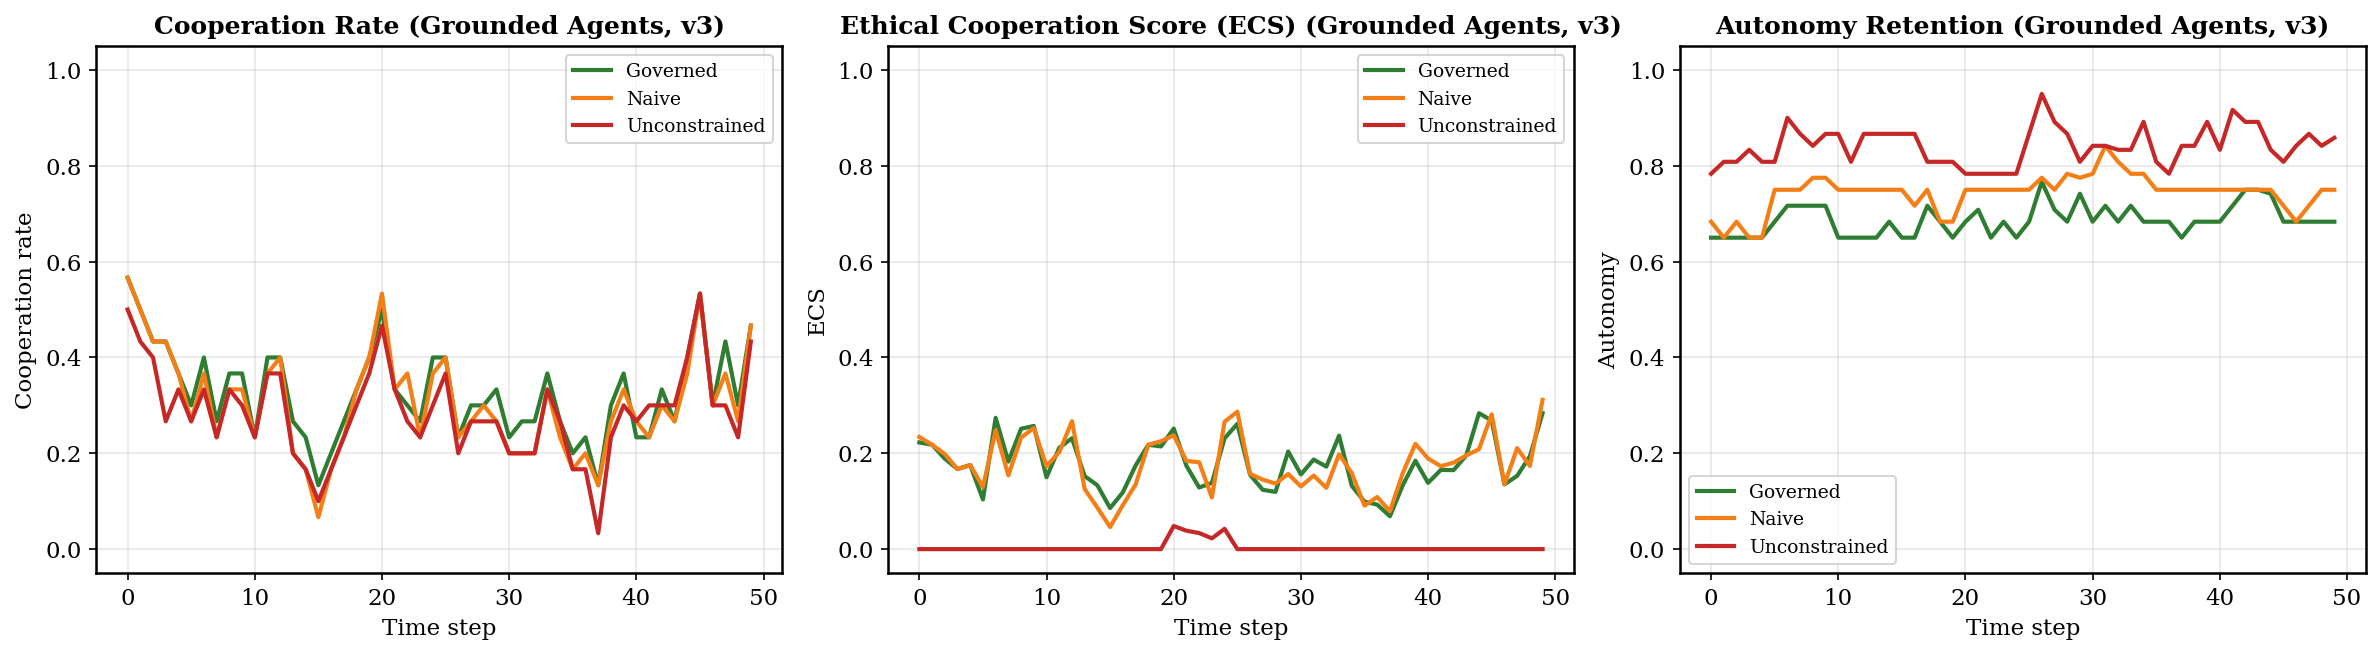

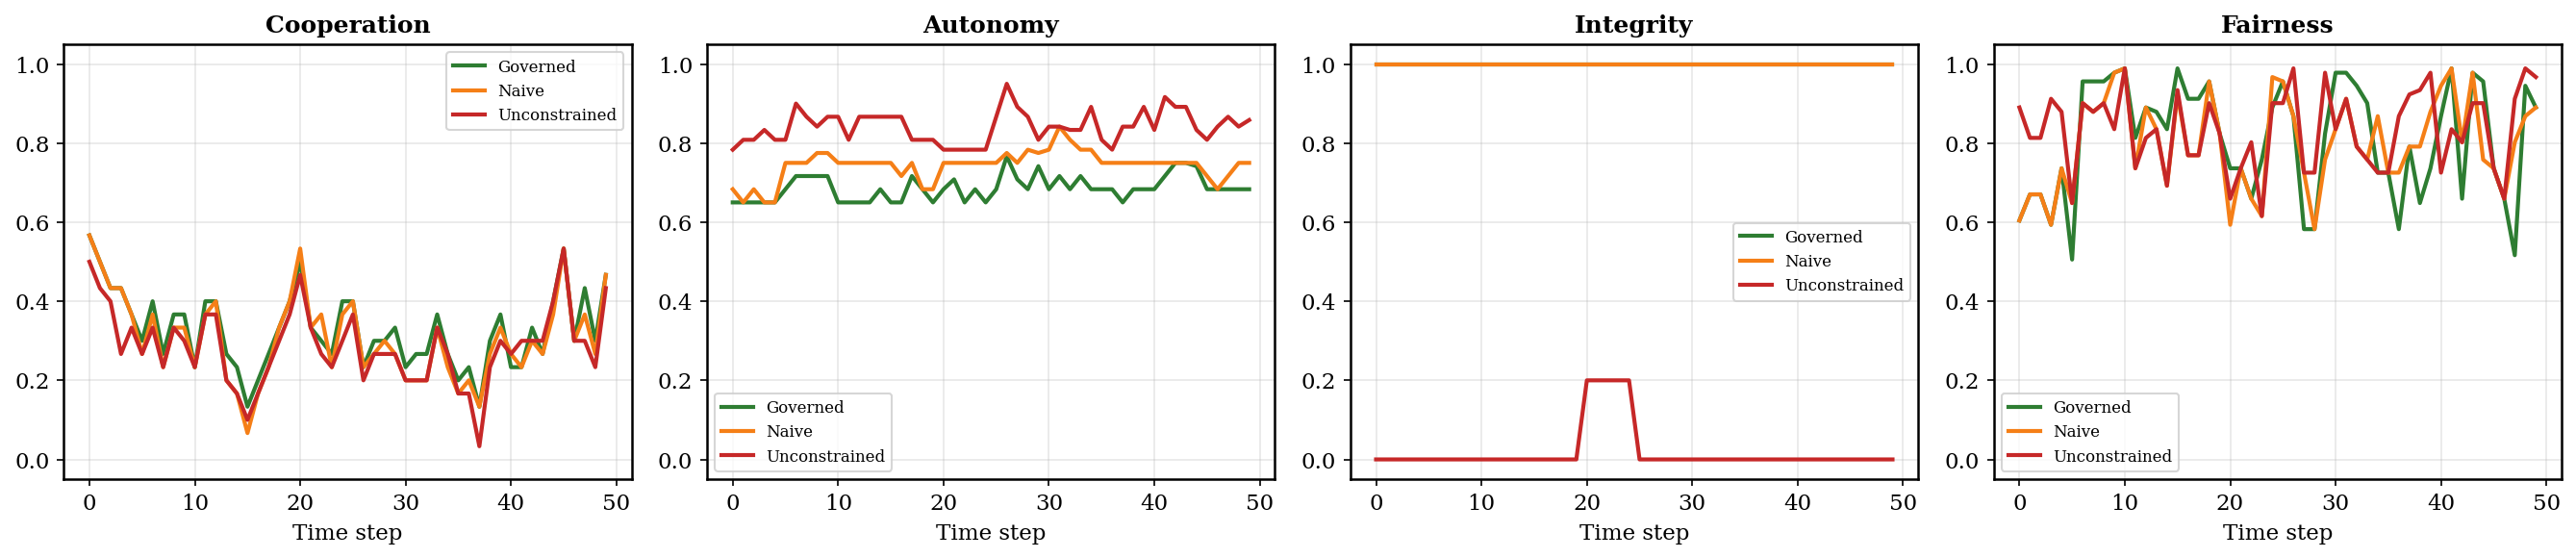

In [36]:
# ============================================================
# 13) EXPERIMENT 1: Governed vs Naive vs Unconstrained (Grounded)
# ============================================================
comp_llm = NebiusLLM(client=client, model=COMPILER_MODEL,
                     temperature=0.25, max_tokens=400, role="compiler",
                     cache_enabled=True)
ag_llm = NebiusLLM(client=client, model=AGENT_MODEL,
                   temperature=0.30, max_tokens=250, role="agent",
                   cache_enabled=True)

BASE = ensure_dir("./paper5_v3")
summaries = []
all_dfs = {}
all_audits = {}

print("\n" + "="*60)
print("EXP 1: Three-condition comparison (grounded agents, adversarial)")
print("="*60)

for mode in ["governed", "naive", "unconstrained"]:
    cfg = GCGEConfig(
        n_agents=30, topo="scale_free", steps=50, seed=42,
        adversarial=True, governance_mode=mode,
        n_candidates=6, label=f"{mode}-adversarial"
    )
    out = ensure_dir(os.path.join(BASE, f"{mode}_adversarial"))
    df, pol_df, audits = run_gcge(cfg, out, comp_llm, ag_llm)
    all_dfs[mode] = df
    all_audits[mode] = audits
    summaries.append(compute_gcge_summary(df, audits, cfg))
    print(f"  {mode}: coop={df['coop_rate'].iloc[-1]:.3f}, "
          f"ECS={df['ecs'].iloc[-1]:.3f}, auto={df['autonomy_retention'].iloc[-1]:.3f}, "
          f"integ={df['epistemic_integrity'].iloc[-1]:.3f}")

plot_three_condition(all_dfs, BASE, " (Grounded Agents, v3)")
plot_ecs_decomposition(all_dfs, BASE)


EXP 2: Governance cost comparison (grounded vs idealized)


idealized-governed:   0%|          | 0/50 [00:00<?, ?it/s]

  Idealized-governed: coop=0.733, ECS=0.348


idealized-unconstrained:   0%|          | 0/50 [00:00<?, ?it/s]

  Idealized-unconstrained: coop=0.967, ECS=0.000

  Grounded governance cost: coop=-0.033, ECS gain=+0.172

  Idealized governance cost: coop=+0.193, ECS gain=+0.563


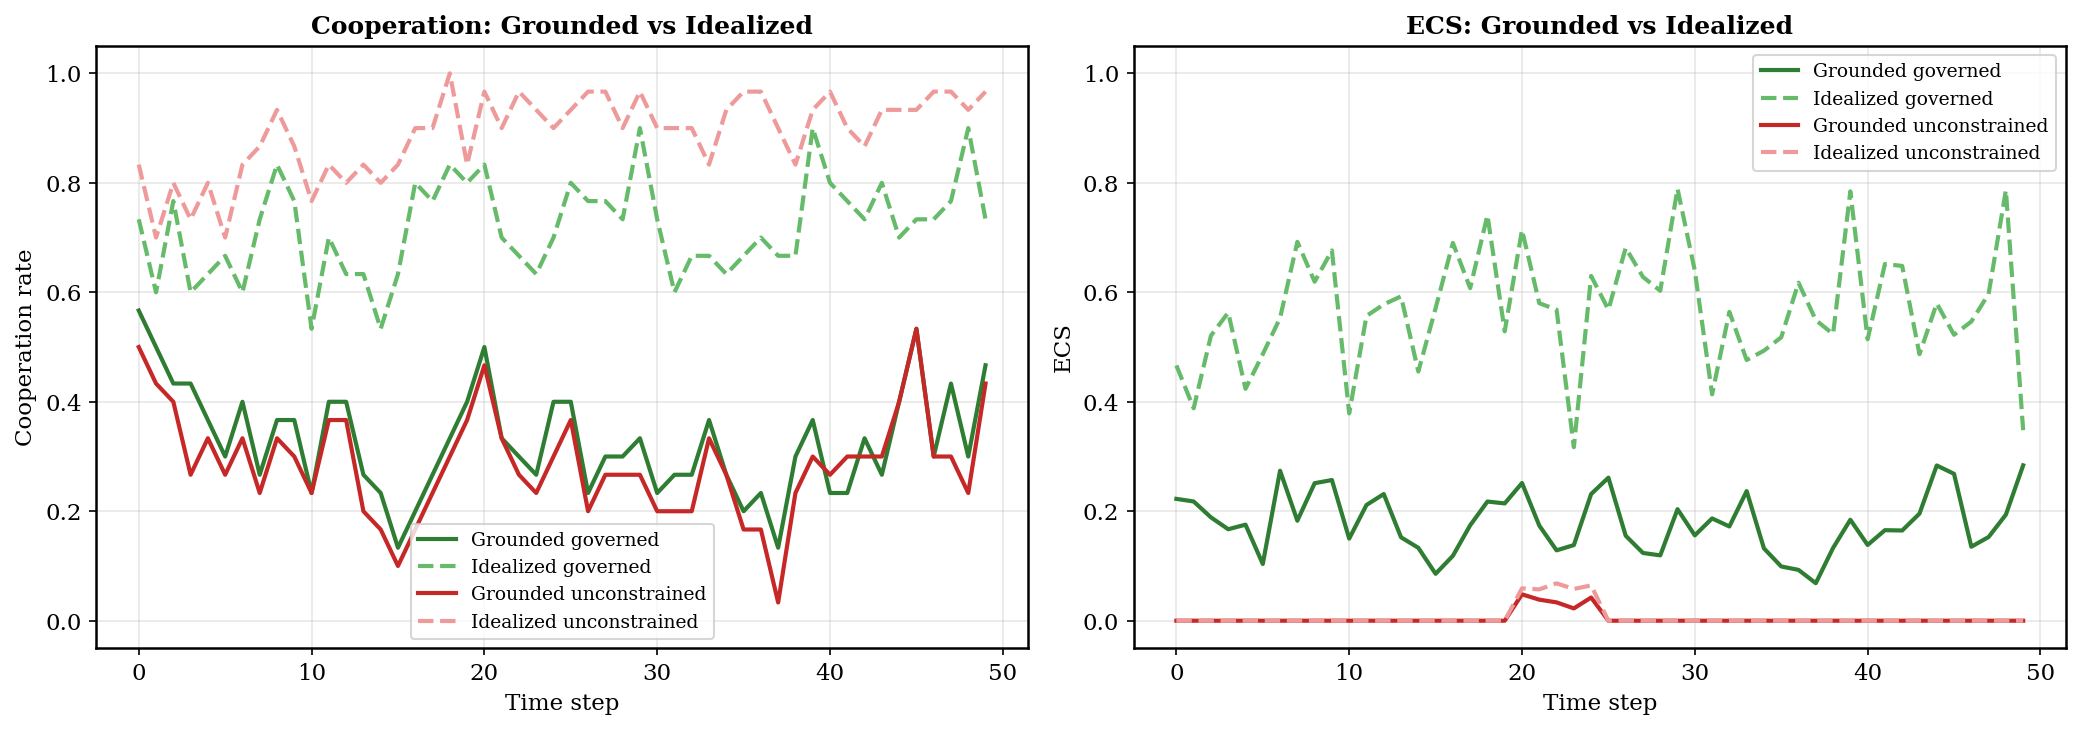

In [37]:
# ============================================================
# 14) EXPERIMENT 2: Governance Cost — Grounded vs Idealized
# ============================================================
print("\n" + "="*60)
print("EXP 2: Governance cost comparison (grounded vs idealized)")
print("="*60)

ideal_dfs = {}
for mode in ["governed", "unconstrained"]:
    cfg = GCGEConfig(n_agents=30, topo="scale_free", steps=50, seed=42,
                     adversarial=True, governance_mode=mode,
                     label=f"idealized-{mode}")
    out = ensure_dir(os.path.join(BASE, f"idealized_{mode}"))
    idf = run_idealized(cfg, out, comp_llm, governance_mode=mode, adversarial=True)
    ideal_dfs[mode] = idf
    print(f"  Idealized-{mode}: coop={idf['coop_rate'].iloc[-1]:.3f}, ECS={idf['ecs'].iloc[-1]:.3f}")

# Compute governance cost in both regimes
for regime, dfs in [("Grounded", all_dfs), ("Idealized", ideal_dfs)]:
    if "governed" in dfs and "unconstrained" in dfs:
        coop_g = dfs["governed"]["coop_rate"].tail(20).mean()
        coop_u = dfs["unconstrained"]["coop_rate"].tail(20).mean()
        ecs_g = dfs["governed"]["ecs"].tail(20).mean()
        ecs_u = dfs["unconstrained"]["ecs"].tail(20).mean()
        print(f"\n  {regime} governance cost: coop={coop_u-coop_g:+.3f}, ECS gain={ecs_g-ecs_u:+.3f}")

plot_grounded_vs_idealized_governance(all_dfs, ideal_dfs, BASE)


EXP 3: Adversarial vs Benign (governed, grounded agents)


governed-adversarial:   0%|          | 0/50 [00:00<?, ?it/s]

  adversarial: coop=0.307, ECS=0.172, rejection_rate=41.7%


governed-benign:   0%|          | 0/50 [00:00<?, ?it/s]

  benign: coop=0.307, ECS=0.172, rejection_rate=5.0%


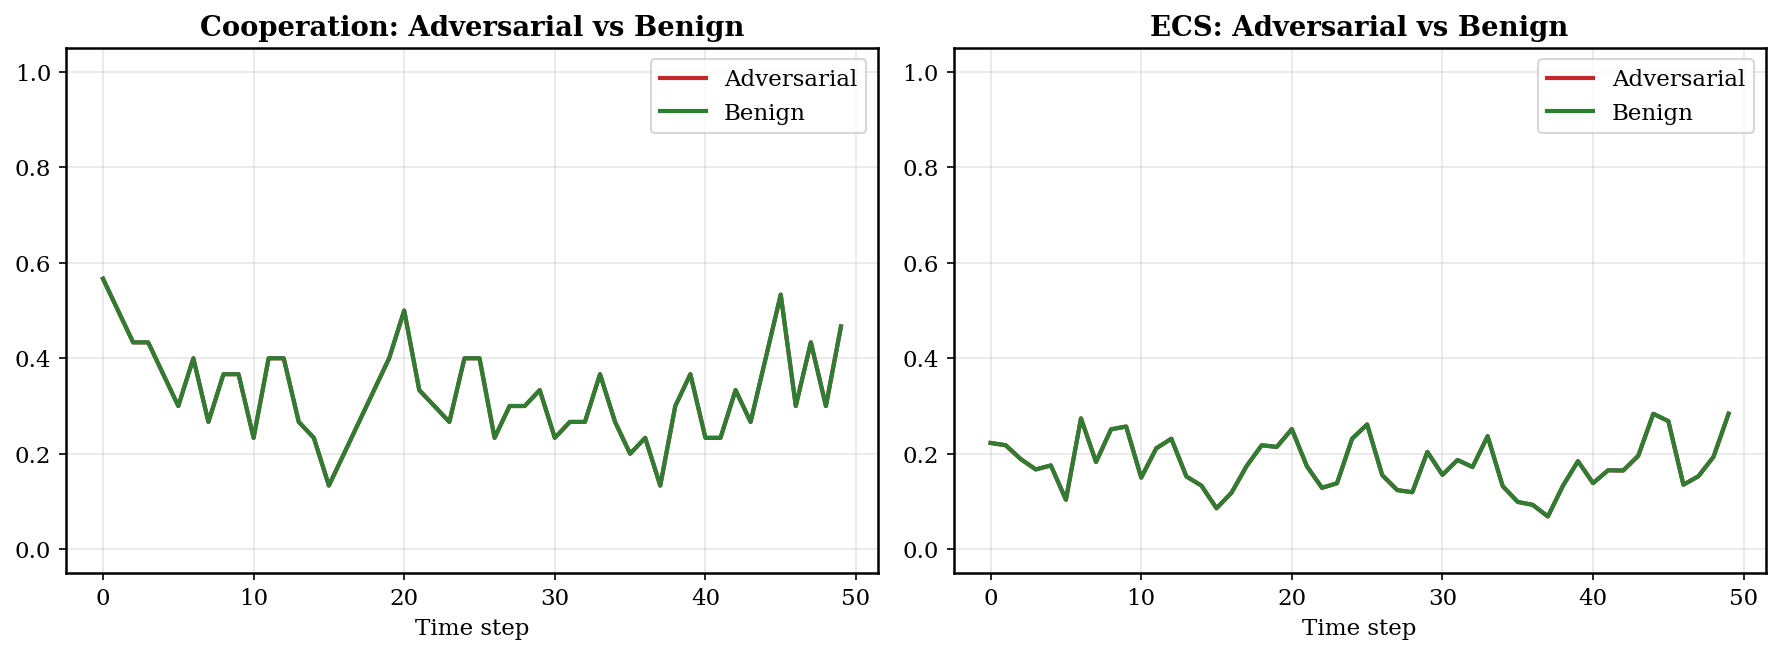

In [38]:
# ============================================================
# 15) EXPERIMENT 3: Adversarial vs Benign (governed, grounded)
# ============================================================
print("\n" + "="*60)
print("EXP 3: Adversarial vs Benign (governed, grounded agents)")
print("="*60)

adv_benign_dfs = {}
for adversarial, label in [(True, "adversarial"), (False, "benign")]:
    cfg = GCGEConfig(
        n_agents=30, topo="scale_free", steps=50, seed=42,
        adversarial=adversarial, governance_mode="governed",
        label=f"governed-{label}"
    )
    out = ensure_dir(os.path.join(BASE, f"governed_{label}"))
    df, _, audits = run_gcge(cfg, out, comp_llm, ag_llm)
    adv_benign_dfs[label] = df
    s = compute_gcge_summary(df, audits, cfg)
    summaries.append(s)
    print(f"  {label}: coop={s['coop_final']:.3f}, ECS={s['ecs_final']:.3f}, "
          f"rejection_rate={s['rejection_rate']:.1%}")

# Compare
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for label, df in adv_benign_dfs.items():
    c = "#C62828" if label == "adversarial" else "#2E7D32"
    axes[0].plot(df["t"], df["coop_rate"], label=label.capitalize(), color=c, linewidth=2)
    axes[1].plot(df["t"], df["ecs"], label=label.capitalize(), color=c, linewidth=2)
axes[0].set_title("Cooperation: Adversarial vs Benign", fontweight="bold")
axes[1].set_title("ECS: Adversarial vs Benign", fontweight="bold")
for ax in axes:
    ax.set_xlabel("Time step"); ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.05)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(BASE, f"exp3_adv_vs_benign.{ext}"), dpi=300, bbox_inches="tight")
plt.show()


EXP 4: Governance x Resistance interaction sweep


governed-R0.10:   0%|          | 0/50 [00:00<?, ?it/s]

  R=0.10 governed: coop=0.308, ECS=0.172


unconstrained-R0.10:   0%|          | 0/50 [00:00<?, ?it/s]

  R=0.10 unconstrained: coop=0.263, ECS=0.000


...

  R=0.55 unconstrained: coop=0.277, ECS=0.000


governed-R0.70:   0%|          | 0/50 [00:00<?, ?it/s]

  R=0.70 governed: coop=0.292, ECS=0.179


unconstrained-R0.70:   0%|          | 0/50 [00:00<?, ?it/s]

  R=0.70 unconstrained: coop=0.278, ECS=0.000

--- Governance ECS advantage at each resistance level ---
  R=0.10: ECS advantage = +0.172
  R=0.25: ECS advantage = +0.172
  R=0.40: ECS advantage = +0.176
  R=0.55: ECS advantage = +0.177
  R=0.70: ECS advantage = +0.179


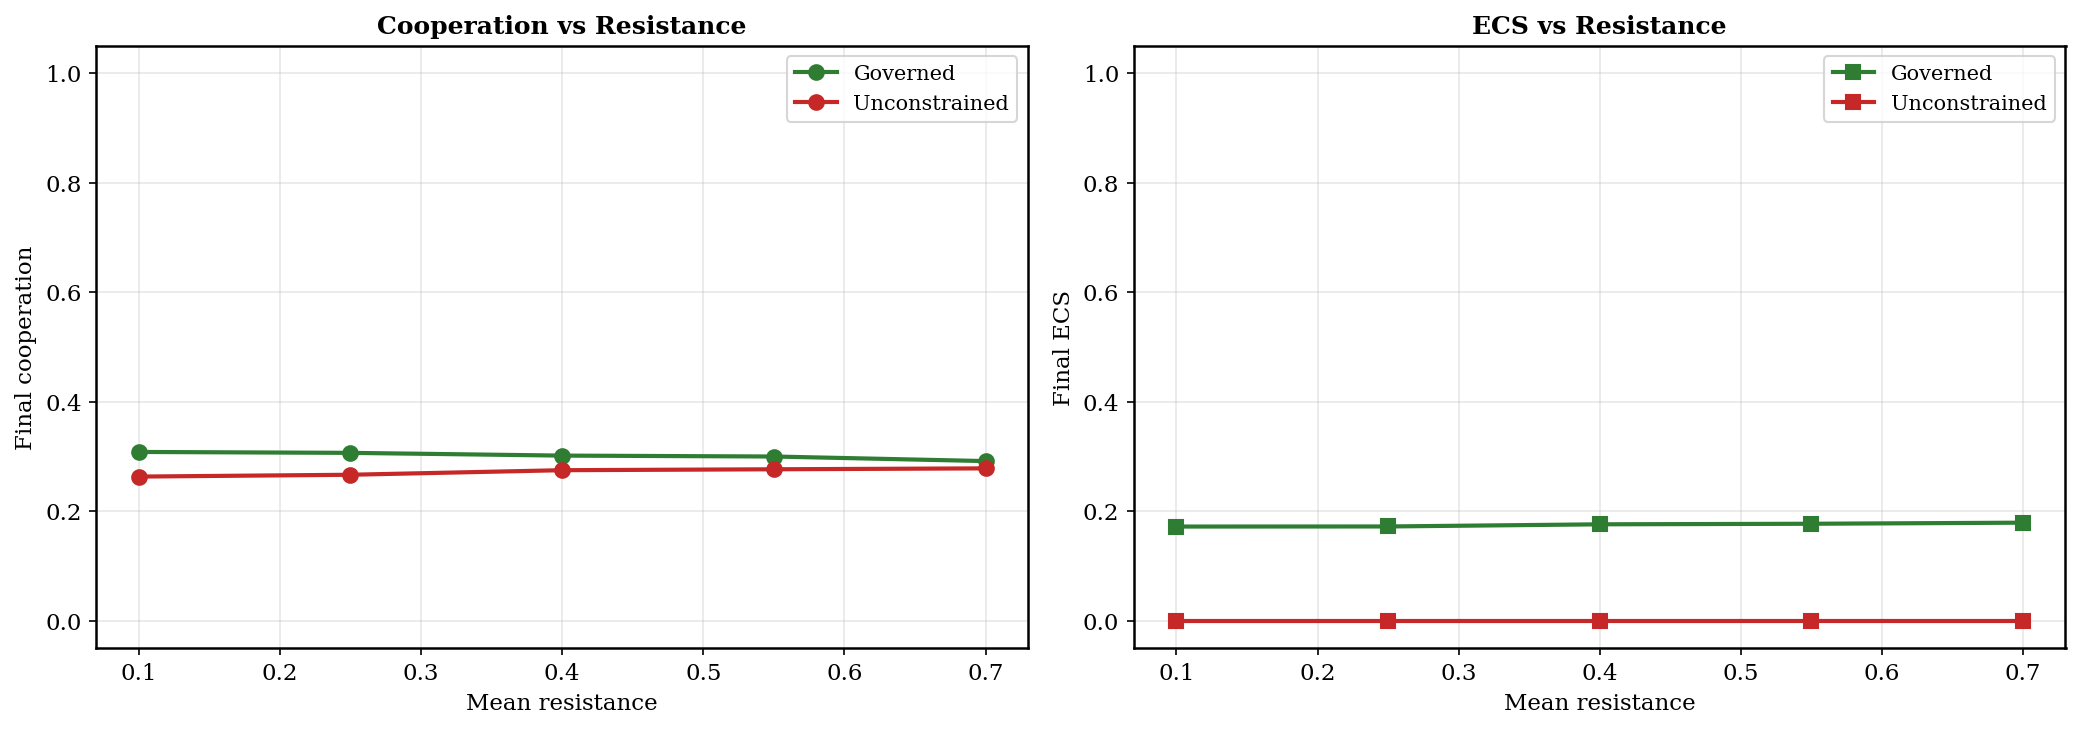

In [39]:
# ============================================================
# 16) EXPERIMENT 4: Governance x Resistance Interaction Sweep
# ============================================================
print("\n" + "="*60)
print("EXP 4: Governance x Resistance interaction sweep")
print("="*60)

resistance_levels = [0.10, 0.25, 0.40, 0.55, 0.70]
sweep_data = {"governed": {}, "unconstrained": {}}

for R in resistance_levels:
    for mode in ["governed", "unconstrained"]:
        cfg = GCGEConfig(
            n_agents=30, topo="scale_free", steps=50, seed=42,
            resistance_mean=R, adversarial=True,
            governance_mode=mode,
            label=f"{mode}-R{R:.2f}"
        )
        out = ensure_dir(os.path.join(BASE, f"sweep_{mode}_R{R:.2f}"))
        df, _, audits = run_gcge(cfg, out, comp_llm, ag_llm)
        last = df.tail(20)
        sweep_data[mode][R] = {
            "coop": float(last["coop_rate"].mean()),
            "ecs": float(last["ecs"].mean()),
            "autonomy": float(last["autonomy_retention"].mean()),
        }
        print(f"  R={R:.2f} {mode}: coop={sweep_data[mode][R]['coop']:.3f}, "
              f"ECS={sweep_data[mode][R]['ecs']:.3f}")

# Governance advantage vs resistance
print("\n--- Governance ECS advantage at each resistance level ---")
for R in resistance_levels:
    g_ecs = sweep_data["governed"][R]["ecs"]
    u_ecs = sweep_data["unconstrained"][R]["ecs"]
    print(f"  R={R:.2f}: ECS advantage = {g_ecs - u_ecs:+.3f}")

plot_resistance_governance_sweep(sweep_data, BASE)

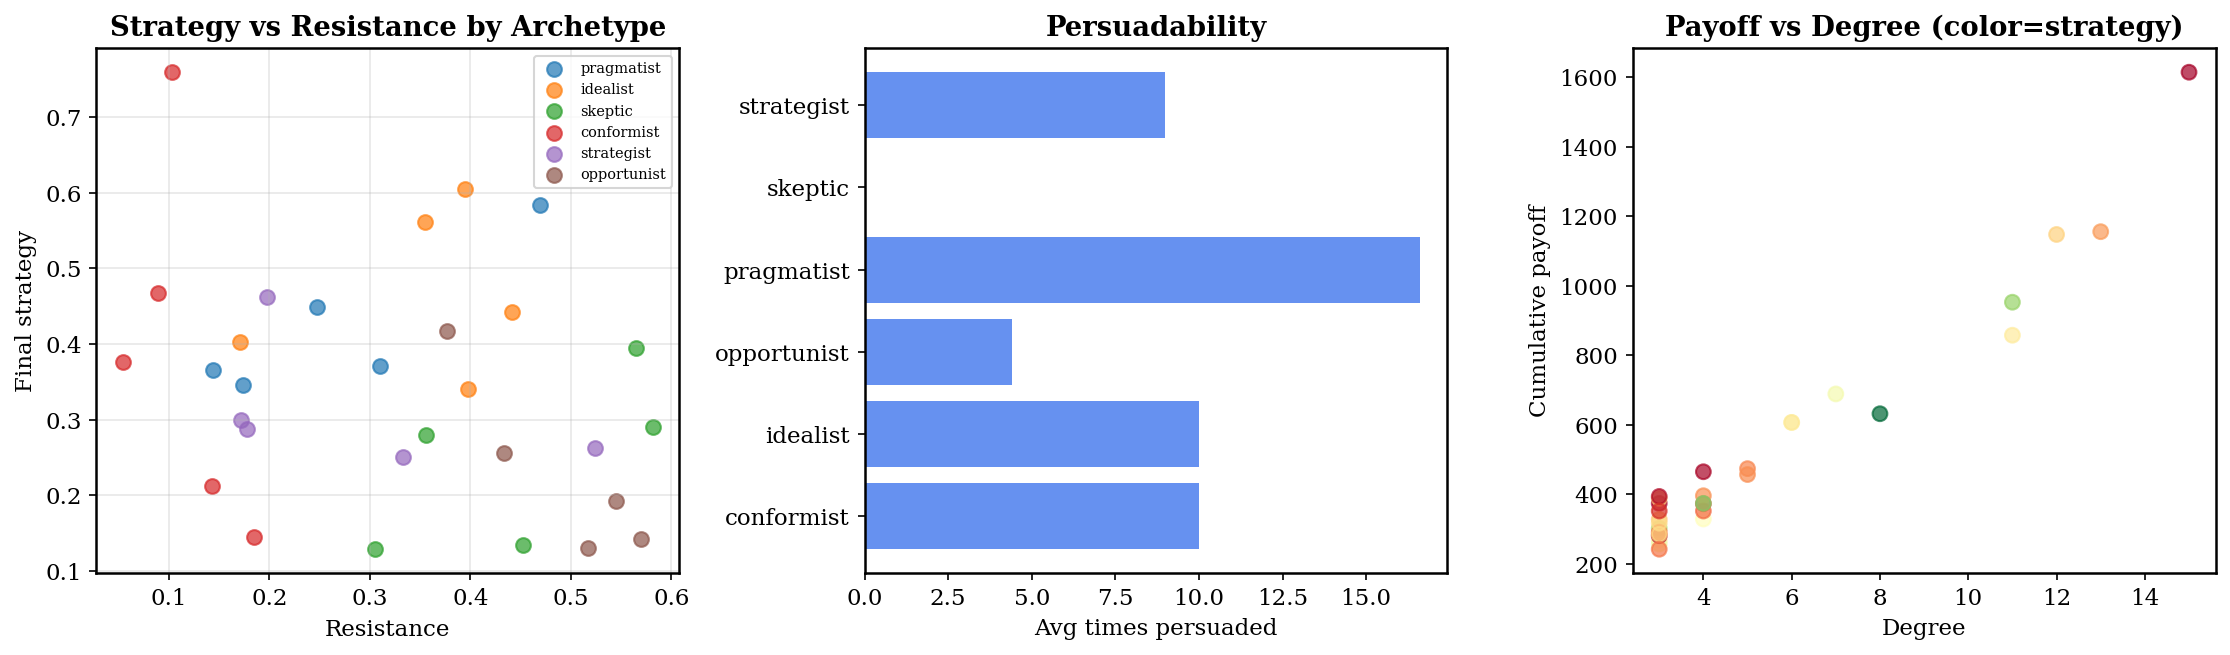


Agent archetype summary (governed + grounded, v3):
            final_strategy        times_persuaded times_targeted  \
                      mean    std             sum            sum   
archetype                                                          
conformist           0.392  0.242              50             50   
idealist             0.470  0.110              50             50   
opportunist          0.227  0.117              22             50   
pragmatist           0.423  0.098              83            100   
skeptic              0.246  0.114               0              0   
strategist           0.313  0.086              45             50   

            times_exploited resistance  
                        sum       mean  
archetype                               
conformist               54      0.115  
idealist                 69      0.352  
opportunist              45      0.488  
pragmatist               51      0.269  
skeptic                  27      0.452  
strateg

In [40]:
# ============================================================
# 17) AGENT-LEVEL ANALYSIS
# ============================================================
# Load agent data from Exp 1 governed run
agent_df = pd.read_csv(os.path.join(BASE, "governed_adversarial", "agents.csv"))
fig_agent_analysis(agent_df, BASE)

# Print archetype summary
print("\nAgent archetype summary (governed + grounded, v3):")
arch_sum = agent_df.groupby("archetype").agg({
    "final_strategy": ["mean", "std"],
    "times_persuaded": "sum",
    "times_targeted": "sum",
    "times_exploited": "sum",
    "resistance": "mean",
}).round(3)
print(arch_sum)

In [41]:
# ============================================================
# 18) CONSOLIDATED SUMMARY TABLE
# ============================================================
sum_df = pd.DataFrame(summaries)
display_cols = ["label", "governance", "coop_final", "ecs_final",
                "autonomy_final", "integrity_final", "fairness_final",
                "avg_shift_final", "backlash_rate_final", "rejection_rate"]
available = [c for c in display_cols if c in sum_df.columns]
print("\n" + "="*60)
print("CONSOLIDATED RESULTS — Paper 5 (GCGE) v3")
print("="*60)
print(sum_df[available].to_string(index=False, float_format="%.3f"))

sum_df.to_csv(os.path.join(BASE, "summary.csv"), index=False)

print(f"\nCompiler LLM stats: {comp_llm.stats}")
print(f"Agent LLM stats:    {ag_llm.stats}")


CONSOLIDATED RESULTS — Paper 5 (GCGE) v3
                    label    governance  coop_final  ecs_final  autonomy_final  integrity_final  fairness_final  avg_shift_final  backlash_rate_final  rejection_rate
     governed-adversarial      governed       0.307      0.172           0.696            1.000           0.810            0.101                0.217           0.417
        naive-adversarial         naive       0.282      0.174           0.756            1.000           0.825            0.072                0.500           0.417
unconstrained-adversarial unconstrained       0.273      0.000           0.850            0.000           0.844            0.046                0.458           0.000
     governed-adversarial      governed       0.307      0.172           0.696            1.000           0.810            0.101                0.217           0.417
          governed-benign      governed       0.307      0.172           0.696            1.000           0.810            0.101


PAPER 5 KEY MESSAGE (v3 — Hybrid Decision Model)

Constitutional governance remains effective with grounded agents.
v3 hybrid decision model creates genuine differentiation:

  GOVERNED: factual, moderate narratives -> stable positive shifts
            -> high integrity + autonomy -> HIGHEST ECS

  UNCONSTRAINED: aggressive/manipulative narratives possible
                 -> larger initial shifts but backlash
                 -> low integrity (MISLEADING claims)
                 -> lower ECS despite comparable cooperation

  NAIVE: simple filtering -> intermediate performance

This completes the 2x2 design matrix:
  Paper 2 (LIC):  Idealized + No governance  -> compilation works
  Paper 3 (CMAG): Idealized + Governance      -> ethics preserved
  Paper 4 (GICE): Grounded  + No governance   -> compilation survives
  Paper 5 (GCGE): Grounded  + Governance       -> ethics survives too


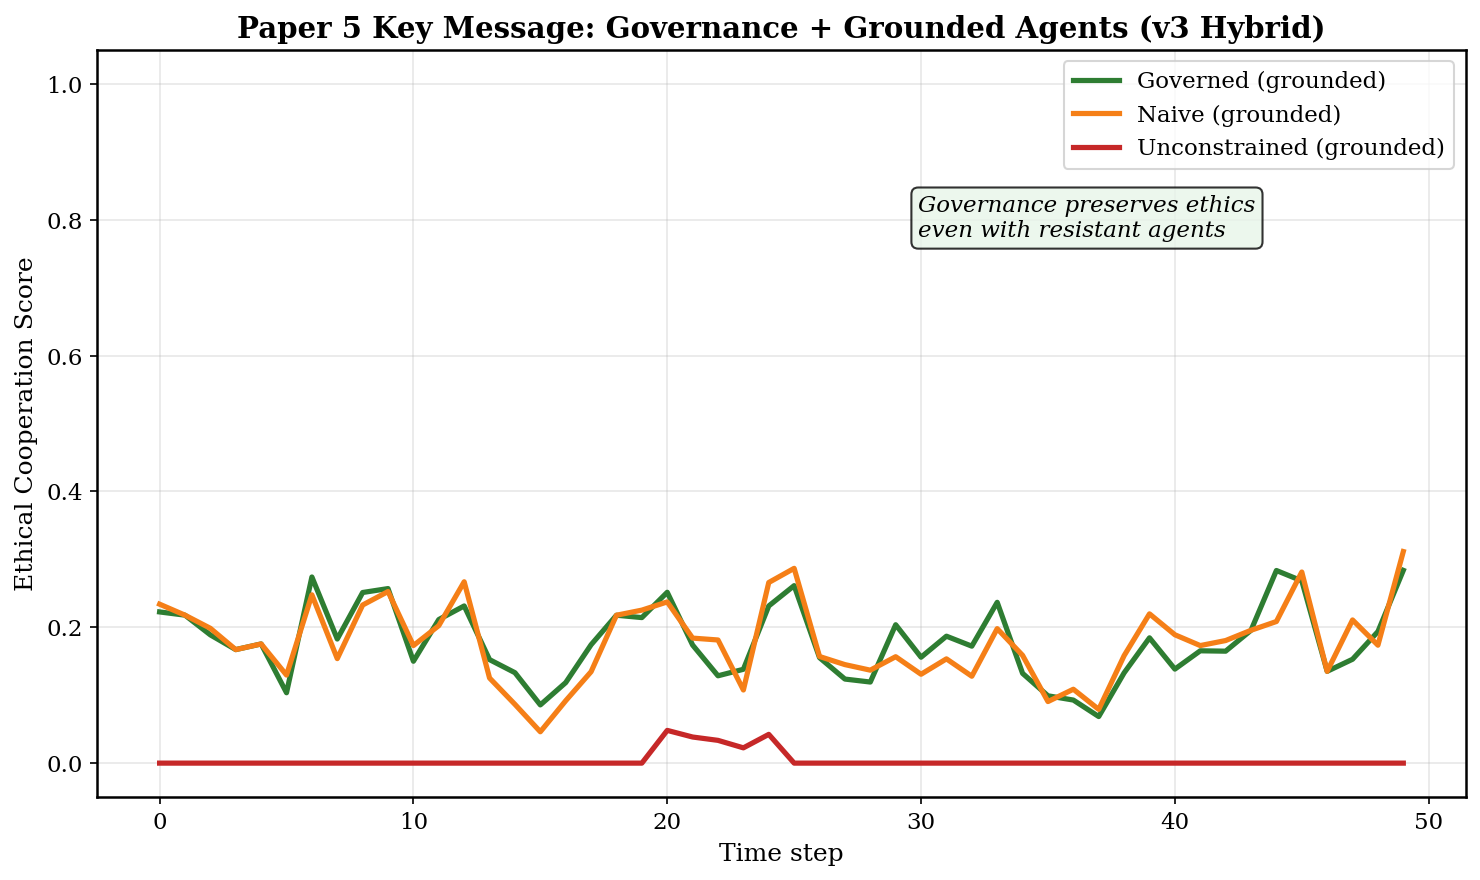

In [42]:
# ============================================================
# 19) FINAL HIGHLIGHT: Paper's key message
# ============================================================
print("\n" + "="*60)
print("PAPER 5 KEY MESSAGE (v3 — Hybrid Decision Model)")
print("="*60)
print()
print("Constitutional governance remains effective with grounded agents.")
print("v3 hybrid decision model creates genuine differentiation:")
print()
print("  GOVERNED: factual, moderate narratives -> stable positive shifts")
print("            -> high integrity + autonomy -> HIGHEST ECS")
print()
print("  UNCONSTRAINED: aggressive/manipulative narratives possible")
print("                 -> larger initial shifts but backlash")
print("                 -> low integrity (MISLEADING claims)")
print("                 -> lower ECS despite comparable cooperation")
print()
print("  NAIVE: simple filtering -> intermediate performance")
print()
print("This completes the 2x2 design matrix:")
print("  Paper 2 (LIC):  Idealized + No governance  -> compilation works")
print("  Paper 3 (CMAG): Idealized + Governance      -> ethics preserved")
print("  Paper 4 (GICE): Grounded  + No governance   -> compilation survives")
print("  Paper 5 (GCGE): Grounded  + Governance       -> ethics survives too")

plot_key_message(all_dfs, BASE)

---
# v4 Sections

Sections R1--R5 below extend the core four experiments with multi-seed
statistical validation and parameter sweeps modeled on the CGS v4
methodology, adapted for GCGE's ECS-based metrics and three-way
governance comparison (governed vs naive vs unconstrained).

All v4 outputs are written to `./paper5_v4` so they can be
packaged separately from the v3 core results.


In [43]:
# ============================================================
# v4 SHARED HELPERS  (multi-seed + sweep aggregation)
# ============================================================
from scipy import stats as sp_stats

V4_BASE = ensure_dir("./paper5_v4")

# Metrics tracked across all v4 sweeps
V4_METRICS = [
    "coop_final", "ecs_final",
    "autonomy_final", "integrity_final",
    "fairness_final", "backlash_rate_final",
]

V4_METRIC_LABELS = {
    "coop_final":           "Coop rate",
    "ecs_final":            "ECS",
    "autonomy_final":       "Autonomy",
    "integrity_final":      "Integrity",
    "fairness_final":       "Fairness",
    "backlash_rate_final":  "Backlash",
}

# Consistent palette for governance modes (matches v3 figures)
V4_COLORS = {
    "governed":      "#2E7D32",
    "naive":         "#F57F17",
    "unconstrained": "#C62828",
}

def gcge_summary_row(df, audits, cfg, **extras):
    """One-row summary in the v4 metric vocabulary; safe for empty audits."""
    last20 = df.tail(20)
    n_rej = sum(a.get("n_rejected", 0) for a in audits) if audits else 0
    n_tot = sum(a.get("n_total", 0)    for a in audits) if audits else 0
    row = {
        "label":                 cfg.label,
        "governance":            cfg.governance_mode,
        "adversarial":           cfg.adversarial,
        "topo":                  cfg.topo,
        "seed":                  cfg.seed,
        "n_agents":              cfg.n_agents,
        "coop_final":            float(last20["coop_rate"].mean()),
        "ecs_final":             float(last20["ecs"].mean()),
        "autonomy_final":        float(last20["autonomy_retention"].mean()),
        "integrity_final":       float(last20["epistemic_integrity"].mean()),
        "fairness_final":        float(last20["subgroup_fairness"].mean()),
        "backlash_rate_final":   float(last20["backlash_rate"].mean())
                                 if "backlash_rate" in last20.columns else 0.0,
        "rejection_rate":        n_rej / max(n_tot, 1),
    }
    row.update(extras)
    return row

def bootstrap_ci(data, stat=np.mean, n_boot=5000, ci=95, seed=42):
    """Non-parametric bootstrap CI; returns (mean_of_boot, lo, hi)."""
    data = np.asarray(data, dtype=float)
    rng  = np.random.default_rng(seed)
    boot = [stat(rng.choice(data, size=len(data), replace=True))
            for _ in range(n_boot)]
    lo = np.percentile(boot, (100 - ci) / 2)
    hi = np.percentile(boot, 100 - (100 - ci) / 2)
    return float(np.mean(boot)), float(lo), float(hi)

def cohens_d(x, y):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    s = np.sqrt((np.std(x, ddof=1)**2 + np.std(y, ddof=1)**2) / 2)
    return float((np.mean(x) - np.mean(y)) / (s + 1e-9))

print("v4 helpers ready.")
print(f"  V4_BASE = {V4_BASE}")
print(f"  Metrics: {V4_METRICS}")


v4 helpers ready.
  V4_BASE = ./paper5_v4
  Metrics: ['coop_final', 'ecs_final', 'autonomy_final', 'integrity_final', 'fairness_final', 'backlash_rate_final']


### R1 -- Multi-Seed Statistical Validation

Replicate the core three-condition comparison (governed vs naive vs
unconstrained, adversarial, scale-free, n=30) across **5 independent seeds**.
For each metric we report the bootstrap 95% CI and a Mann-Whitney U test
between governed and unconstrained (Bonferroni-corrected across the 6 metrics).
This isolates whether the ECS gap reported in Experiment 1 survives
seed variability.


In [44]:
# ============================================================
# R1) MULTI-SEED REPLICATION (5 seeds x 3 governance conditions)
# ============================================================
SEEDS_MS    = [0, 1, 2, 3, 4]
CONDS_MS    = ["governed", "naive", "unconstrained"]
BASE_MS     = ensure_dir(os.path.join(V4_BASE, "multi_seed"))
ms_records  = []

print("Running multi-seed replication ...")
print(f"  Seeds:      {SEEDS_MS}")
print(f"  Conditions: {CONDS_MS}")
print(f"  Total runs: {len(SEEDS_MS) * len(CONDS_MS)} "
      f"(adversarial=True, n_agents=30, scale_free, T=50)\n")

for seed in SEEDS_MS:
    for mode in CONDS_MS:
        label = f"{mode}-s{seed}"
        out   = ensure_dir(os.path.join(BASE_MS, label))
        cfg   = GCGEConfig(
            n_agents=30, topo="scale_free", steps=50, seed=seed,
            adversarial=True, governance_mode=mode,
            n_candidates=6, label=label,
        )
        df, _, audits = run_gcge(cfg, out, comp_llm, ag_llm, verbose=False)
        s = gcge_summary_row(df, audits, cfg, condition=mode, seed=seed)
        ms_records.append(s)
        print(f"  [{mode:13s} | seed {seed}]  "
              f"coop={s['coop_final']:.3f}  ECS={s['ecs_final']:.3f}  "
              f"auto={s['autonomy_final']:.3f}  integ={s['integrity_final']:.3f}  "
              f"backlash={s['backlash_rate_final']:.3f}")

ms_df = pd.DataFrame(ms_records)
ms_df.to_csv(os.path.join(BASE_MS, "multi_seed_summary.csv"), index=False)
print(f"\nSaved -> {BASE_MS}/multi_seed_summary.csv")


Running multi-seed replication ...
  Seeds:      [0, 1, 2, 3, 4]
  Conditions: ['governed', 'naive', 'unconstrained']
  Total runs: 15 (adversarial=True, n_agents=30, scale_free, T=50)

  [governed      | seed 0]  coop=0.277  ECS=0.175  auto=0.757  integ=1.000  backlash=0.492
  [naive         | seed 0]  coop=0.272  ECS=0.180  auto=0.779  integ=1.000  backlash=0.483
  [unconstrained | seed 0]  coop=0.255  ECS=0.000  auto=0.847  integ=0.000  backlash=0.608
  [governed      | seed 1]  coop=0.318  ECS=0.177  auto=0.688  integ=1.000  backlash=0.175
  [naive         | seed 1]  coop=0.312  ECS=0.186  auto=0.730  integ=1.000  backlash=0.325
  [unconstrained | seed 1]  coop=0.308  ECS=0.000  auto=0.820  integ=0.000  backlash=0.542
  [governed      | seed 2]  coop=0.285  ECS=0.160  auto=0.681  integ=1.000  backlash=0.142
  [naive         | seed 2]  coop=0.277  ECS=0.159  auto=0.740  integ=1.000  backlash=0.392
  [unconstrained | seed 2]  coop=0.257  ECS=0.010  auto=0.867  integ=0.050  backlash=0

In [45]:
# ============================================================
# R1-b) BOOTSTRAP 95% CIs across seeds (per condition x metric)
# ============================================================
print("Bootstrap 95% CIs (5000 resamples, n_seeds=5)\n")
header = f"{'Metric':<22}"
for cond in CONDS_MS:
    header += f"{cond.capitalize():>30}"
print(header)
print("-" * len(header))

ci_records = []
for metric in V4_METRICS:
    row = {"metric": metric}
    line = f"  {V4_METRIC_LABELS[metric]:<20}"
    for cond in CONDS_MS:
        data = ms_df[ms_df["condition"] == cond][metric].values
        mu, lo, hi = bootstrap_ci(data)
        row[f"{cond}_mean"] = mu
        row[f"{cond}_lo95"] = lo
        row[f"{cond}_hi95"] = hi
        line += f"  {mu:.3f} [{lo:.3f}, {hi:.3f}]".rjust(30)
    ci_records.append(row)
    print(line)

ci_df = pd.DataFrame(ci_records)
ci_df.to_csv(os.path.join(BASE_MS, "bootstrap_ci.csv"), index=False)
print(f"\nSaved -> {BASE_MS}/bootstrap_ci.csv")


Bootstrap 95% CIs (5000 resamples, n_seeds=5)

Metric                                      Governed                         Naive                 Unconstrained
----------------------------------------------------------------------------------------------------------------
  Coop rate                     0.275 [0.241, 0.302]          0.269 [0.237, 0.295]          0.257 [0.228, 0.287]
  ECS                           0.163 [0.150, 0.174]          0.167 [0.156, 0.180]          0.011 [0.000, 0.028]
  Autonomy                      0.725 [0.690, 0.761]          0.758 [0.722, 0.801]          0.842 [0.821, 0.862]
  Integrity                     1.000 [1.000, 1.000]          1.000 [1.000, 1.000]          0.071 [0.000, 0.190]
  Fairness                      0.825 [0.815, 0.834]          0.826 [0.807, 0.841]          0.816 [0.779, 0.853]
  Backlash                      0.309 [0.172, 0.445]          0.425 [0.287, 0.587]          0.605 [0.505, 0.712]

Saved -> ./paper5_v4/multi_seed/bootstrap_ci.csv

In [46]:
# ============================================================
# R1-c) MANN-WHITNEY U TESTS (governed vs unconstrained, Bonferroni)
# ============================================================
n_comp = len(V4_METRICS)
print(f"Mann-Whitney U: governed vs unconstrained "
      f"(Bonferroni m={n_comp}, two-sided)\n")
print(f"  {'Metric':<20}  {'U':>8}  {'p_raw':>10}  {'p_Bonf':>10}  {'d':>8}  sig")
print("-" * 72)

mw_records = []
for metric in V4_METRICS:
    x_g = ms_df[ms_df["condition"] == "governed"][metric].values
    x_u = ms_df[ms_df["condition"] == "unconstrained"][metric].values
    # If one column is constant (e.g. integrity) the U test still runs
    try:
        U, p_raw = sp_stats.mannwhitneyu(x_g, x_u, alternative="two-sided")
    except ValueError:
        U, p_raw = np.nan, 1.0
    p_bonf = min(p_raw * n_comp, 1.0)
    d      = cohens_d(x_g, x_u)
    sig    = ("***" if p_bonf < 0.001 else
              "**"  if p_bonf < 0.01  else
              "*"   if p_bonf < 0.05  else "ns")
    print(f"  {V4_METRIC_LABELS[metric]:<20}  {U:8.1f}  "
          f"{p_raw:10.4f}  {p_bonf:10.4f}  {d:8.3f}  {sig}")
    mw_records.append({
        "metric": metric, "U": U, "p_raw": p_raw,
        "p_bonf": p_bonf, "cohens_d": d, "sig": sig,
        "comparison": "governed_vs_unconstrained",
    })

# Also report governed vs naive (the closer comparison)
print(f"\nMann-Whitney U: governed vs naive (Bonferroni m={n_comp}, two-sided)\n")
print(f"  {'Metric':<20}  {'U':>8}  {'p_raw':>10}  {'p_Bonf':>10}  {'d':>8}  sig")
print("-" * 72)
for metric in V4_METRICS:
    x_g = ms_df[ms_df["condition"] == "governed"][metric].values
    x_n = ms_df[ms_df["condition"] == "naive"][metric].values
    try:
        U, p_raw = sp_stats.mannwhitneyu(x_g, x_n, alternative="two-sided")
    except ValueError:
        U, p_raw = np.nan, 1.0
    p_bonf = min(p_raw * n_comp, 1.0)
    d      = cohens_d(x_g, x_n)
    sig    = ("***" if p_bonf < 0.001 else
              "**"  if p_bonf < 0.01  else
              "*"   if p_bonf < 0.05  else "ns")
    print(f"  {V4_METRIC_LABELS[metric]:<20}  {U:8.1f}  "
          f"{p_raw:10.4f}  {p_bonf:10.4f}  {d:8.3f}  {sig}")
    mw_records.append({
        "metric": metric, "U": U, "p_raw": p_raw,
        "p_bonf": p_bonf, "cohens_d": d, "sig": sig,
        "comparison": "governed_vs_naive",
    })

mw_df = pd.DataFrame(mw_records)
mw_df.to_csv(os.path.join(BASE_MS, "mannwhitney_tests.csv"), index=False)
print(f"\nSaved -> {BASE_MS}/mannwhitney_tests.csv")


Mann-Whitney U: governed vs unconstrained (Bonferroni m=6, two-sided)

  Metric                       U       p_raw      p_Bonf         d  sig
------------------------------------------------------------------------
  Coop rate                 18.0      0.3095      1.0000     0.494  ns
  ECS                       25.0      0.0112      0.0670     8.678  ns
  Autonomy                   0.0      0.0079      0.0476    -3.154  *
  Integrity                 25.0      0.0067      0.0402    10.087  *
  Fairness                  13.0      1.0000      1.0000     0.246  ns
  Backlash                   2.0      0.0317      0.1905    -1.903  ns

Mann-Whitney U: governed vs naive (Bonferroni m=6, two-sided)

  Metric                       U       p_raw      p_Bonf         d  sig
------------------------------------------------------------------------
  Coop rate                 17.5      0.3457      1.0000     0.174  ns
  ECS                       11.0      0.8413      1.0000    -0.249  ns
  Autonom

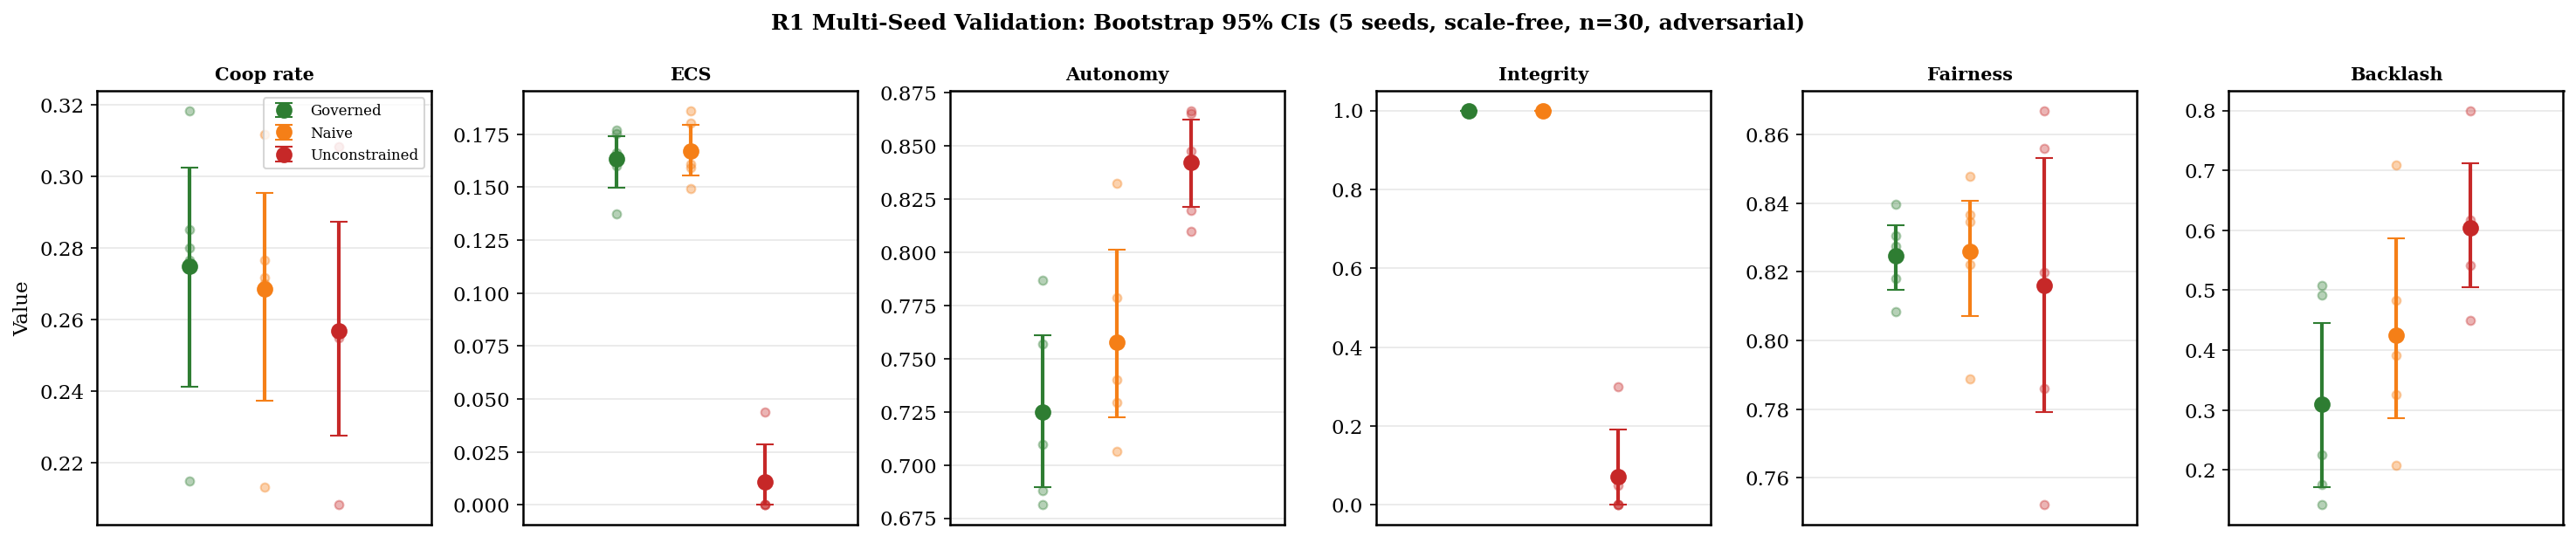

Saved -> ./paper5_v4/multi_seed/forest_plot.png + .pdf


In [47]:
# ============================================================
# R1-d) FOREST PLOT  (per-metric CI panel across conditions)
# ============================================================
OFFSETS = {"governed": -0.20, "naive": 0.00, "unconstrained": 0.20}

fig, axes = plt.subplots(1, len(V4_METRICS),
                         figsize=(3.3 * len(V4_METRICS), 4.2))
fig.suptitle(
    f"R1 Multi-Seed Validation: Bootstrap 95% CIs "
    f"({len(SEEDS_MS)} seeds, scale-free, n=30, adversarial)",
    fontsize=12, fontweight="bold")

for ax, metric in zip(axes, V4_METRICS):
    for cond in CONDS_MS:
        row = ci_df[ci_df["metric"] == metric].iloc[0]
        mu  = row[f"{cond}_mean"]
        lo  = row[f"{cond}_lo95"]
        hi  = row[f"{cond}_hi95"]
        x   = OFFSETS[cond]
        ax.errorbar(x, mu, yerr=[[mu - lo], [hi - mu]],
                    fmt="o", color=V4_COLORS[cond], capsize=5,
                    markersize=8, lw=2,
                    label=cond.capitalize() if ax is axes[0] else None)
        seed_vals = ms_df[ms_df["condition"] == cond][metric].values
        ax.scatter([x] * len(seed_vals), seed_vals,
                   color=V4_COLORS[cond], alpha=0.35, s=22, zorder=3)
    ax.set_xlim(-0.45, 0.45); ax.set_xticks([])
    ax.set_title(V4_METRIC_LABELS[metric], fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel("Value")
        ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.savefig(os.path.join(BASE_MS, "forest_plot.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(BASE_MS, "forest_plot.pdf"),
            bbox_inches="tight")
plt.show(); plt.close()
print(f"Saved -> {BASE_MS}/forest_plot.png + .pdf")


### R2 -- Topology Robustness Sweep

Re-run the governed vs unconstrained comparison on **three network
topologies**: Barabasi-Albert scale-free (the paper baseline),
Watts-Strogatz small-world, and Erdos-Renyi random. This directly
addresses the paper's Limitations note that *robustness to other
topologies, clustered small-world, modular, or hierarchical, remains
to be verified*.

Three seeds per topology give per-topology CIs; the focal quantity is
the ECS gap (governed - unconstrained), which the paper claims is a
structural property of the constitutional filter rather than a
topology artefact.


In [48]:
# ============================================================
# R2) TOPOLOGY ROBUSTNESS  (3 topos x 2 conditions x 3 seeds)
# ============================================================
TOPOS_R2    = ["scale_free", "small_world", "erdos_renyi"]
CONDS_R2    = ["governed", "unconstrained"]
SEEDS_R2    = [0, 1, 2]
BASE_R2     = ensure_dir(os.path.join(V4_BASE, "topology"))
topo_records = []

print("Running topology robustness sweep ...")
print(f"  Topos:      {TOPOS_R2}")
print(f"  Conditions: {CONDS_R2}")
print(f"  Seeds:      {SEEDS_R2}")
print(f"  Total runs: {len(TOPOS_R2) * len(CONDS_R2) * len(SEEDS_R2)}\n")

for topo in TOPOS_R2:
    for mode in CONDS_R2:
        for seed in SEEDS_R2:
            label = f"{mode}-{topo}-s{seed}"
            out   = ensure_dir(os.path.join(BASE_R2, label))
            cfg   = GCGEConfig(
                n_agents=30, topo=topo, steps=50, seed=seed,
                adversarial=True, governance_mode=mode,
                n_candidates=6, label=label,
            )
            df, _, audits = run_gcge(cfg, out, comp_llm, ag_llm, verbose=False)
            s = gcge_summary_row(df, audits, cfg, condition=mode)
            topo_records.append(s)
            print(f"  [{topo:11s} | {mode:13s} | s{seed}]  "
                  f"coop={s['coop_final']:.3f}  ECS={s['ecs_final']:.3f}  "
                  f"integ={s['integrity_final']:.3f}")

topo_df = pd.DataFrame(topo_records)
topo_df.to_csv(os.path.join(BASE_R2, "topology_summary.csv"), index=False)
print(f"\nSaved -> {BASE_R2}/topology_summary.csv")


Running topology robustness sweep ...
  Topos:      ['scale_free', 'small_world', 'erdos_renyi']
  Conditions: ['governed', 'unconstrained']
  Seeds:      [0, 1, 2]
  Total runs: 18

  [scale_free  | governed      | s0]  coop=0.277  ECS=0.175  integ=1.000
  [scale_free  | governed      | s1]  coop=0.318  ECS=0.177  integ=1.000
  [scale_free  | governed      | s2]  coop=0.285  ECS=0.160  integ=1.000
  [scale_free  | unconstrained | s0]  coop=0.255  ECS=0.000  integ=0.000
  [scale_free  | unconstrained | s1]  coop=0.308  ECS=0.000  integ=0.000
  [scale_free  | unconstrained | s2]  coop=0.257  ECS=0.010  integ=0.050
  [small_world | governed      | s0]  coop=0.277  ECS=0.165  integ=1.000
  [small_world | governed      | s1]  coop=0.310  ECS=0.185  integ=1.000
  [small_world | governed      | s2]  coop=0.257  ECS=0.168  integ=1.000
  [small_world | unconstrained | s0]  coop=0.267  ECS=0.000  integ=0.000
  [small_world | unconstrained | s1]  coop=0.298  ECS=0.000  integ=0.000
  [small_world

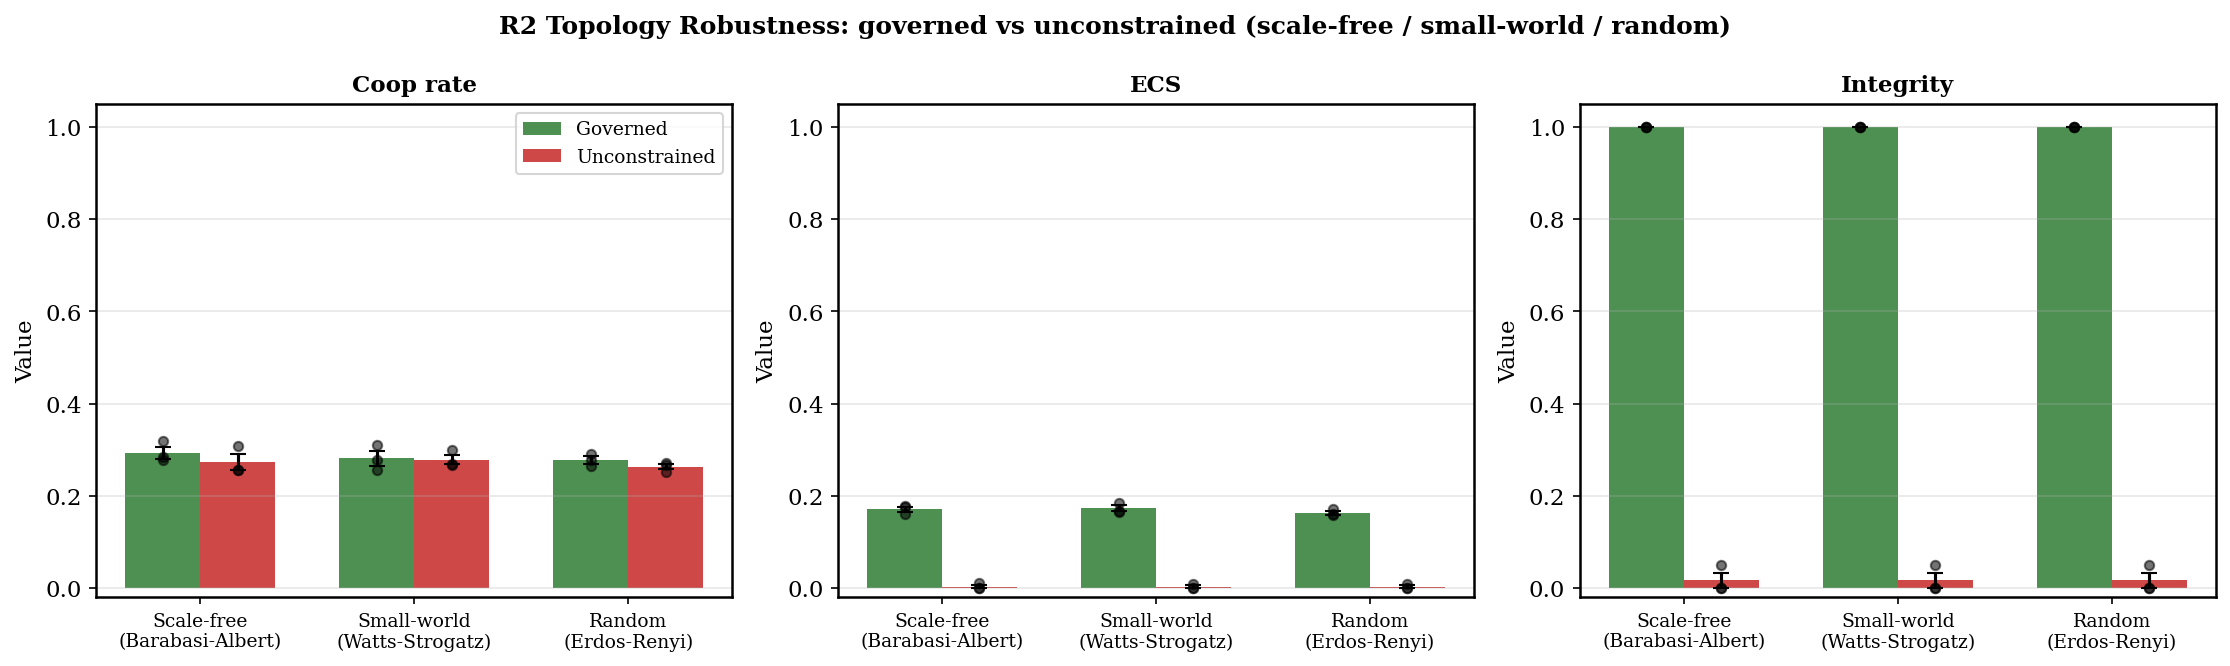

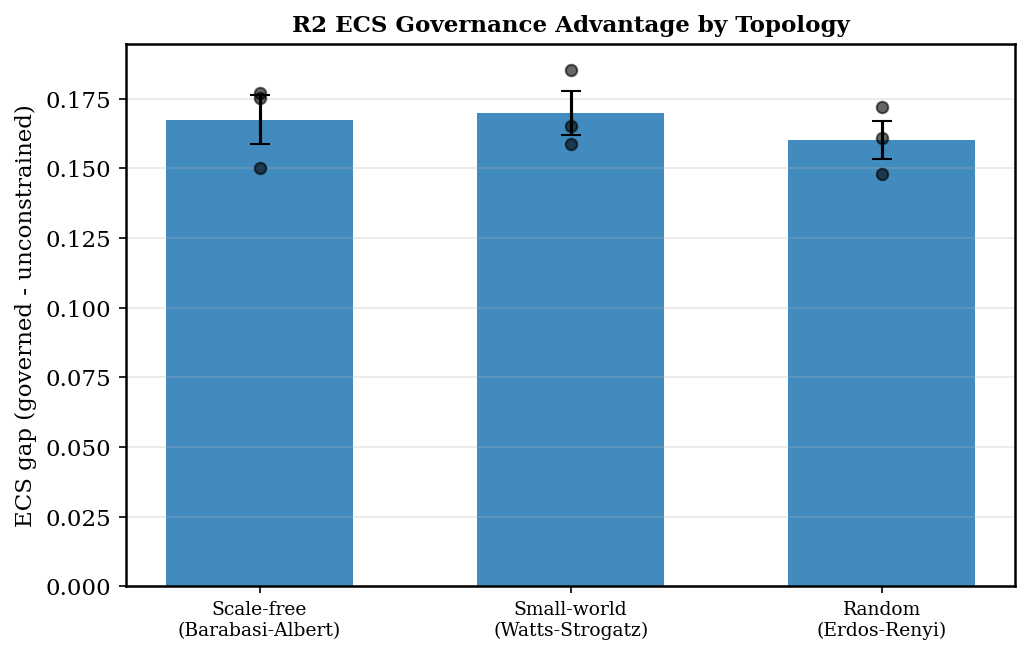

Saved -> ./paper5_v4/topology/


In [49]:
# ============================================================
# R2-b) TOPOLOGY ROBUSTNESS PLOTS  (ECS gap by topology)
# ============================================================
TOPO_LABELS = {
    "scale_free":  "Scale-free\n(Barabasi-Albert)",
    "small_world": "Small-world\n(Watts-Strogatz)",
    "erdos_renyi": "Random\n(Erdos-Renyi)",
}

# 1) Bar chart of governed vs unconstrained ECS, with per-seed dots and error bars
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("R2 Topology Robustness: governed vs unconstrained "
             "(scale-free / small-world / random)",
             fontsize=12, fontweight="bold")

for ax, metric in zip(axes, ["coop_final", "ecs_final", "integrity_final"]):
    width = 0.35
    x_pos = np.arange(len(TOPOS_R2))
    for j, mode in enumerate(CONDS_R2):
        means, sems, dots_x, dots_y = [], [], [], []
        for k, topo in enumerate(TOPOS_R2):
            sub = topo_df[(topo_df["topo"] == topo) &
                          (topo_df["condition"] == mode)][metric].values
            means.append(np.mean(sub))
            sems.append(np.std(sub, ddof=1) / np.sqrt(max(len(sub), 1)))
            x = x_pos[k] + (j - 0.5) * width
            dots_x.extend([x] * len(sub)); dots_y.extend(sub.tolist())
        ax.bar(x_pos + (j - 0.5) * width, means, width=width,
               yerr=sems, capsize=4,
               color=V4_COLORS[mode], alpha=0.85,
               label=mode.capitalize() if ax is axes[0] else None)
        ax.scatter(dots_x, dots_y, s=20, color="black", alpha=0.55, zorder=4)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([TOPO_LABELS[t] for t in TOPOS_R2], fontsize=9)
    ax.set_title(V4_METRIC_LABELS[metric], fontsize=11, fontweight="bold")
    ax.set_ylabel("Value"); ax.grid(True, axis="y", alpha=0.3)
    ax.set_ylim(-0.02, 1.05)
    if ax is axes[0]:
        ax.legend(fontsize=9, loc="best")

plt.tight_layout()
plt.savefig(os.path.join(BASE_R2, "topology_bars.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(BASE_R2, "topology_bars.pdf"),
            bbox_inches="tight")
plt.show(); plt.close()

# 2) ECS gap (governed - unconstrained) per topology, with per-seed dots
fig, ax = plt.subplots(figsize=(7, 4.5))
gap_records = []
for topo in TOPOS_R2:
    sub_g = topo_df[(topo_df["topo"] == topo) &
                    (topo_df["condition"] == "governed")].sort_values("seed")
    sub_u = topo_df[(topo_df["topo"] == topo) &
                    (topo_df["condition"] == "unconstrained")].sort_values("seed")
    gaps  = sub_g["ecs_final"].values - sub_u["ecs_final"].values
    for s_, g_ in zip(sub_g["seed"].values, gaps):
        gap_records.append({"topo": topo, "seed": int(s_), "ecs_gap": float(g_)})

gap_df = pd.DataFrame(gap_records)
gap_df.to_csv(os.path.join(BASE_R2, "ecs_gap_by_topology.csv"), index=False)

for k, topo in enumerate(TOPOS_R2):
    sub = gap_df[gap_df["topo"] == topo]["ecs_gap"].values
    ax.bar(k, sub.mean(),
           yerr=sub.std(ddof=1) / np.sqrt(len(sub)),
           capsize=5, color="#1f77b4", alpha=0.85, width=0.6)
    ax.scatter([k] * len(sub), sub, s=30, color="black", alpha=0.6, zorder=4)
ax.set_xticks(range(len(TOPOS_R2)))
ax.set_xticklabels([TOPO_LABELS[t] for t in TOPOS_R2], fontsize=9)
ax.set_ylabel("ECS gap (governed - unconstrained)")
ax.set_title("R2 ECS Governance Advantage by Topology",
             fontsize=11, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_R2, "ecs_gap_by_topology.png"),
            dpi=300, bbox_inches="tight")
plt.show(); plt.close()
print(f"Saved -> {BASE_R2}/")


### R3 -- One-At-a-Time (OAT) Sensitivity Analysis

Five GCGE hyperparameters swept one-at-a-time around their paper baseline,
reporting Normalised Sensitivity Indices (NSI) for the 4 main outputs
(coop, ECS, autonomy, integrity).

| Parameter        | Baseline | Grid                               |
|------------------|----------|------------------------------------|
| `target_frac`    | 0.20     | 0.10, 0.15, 0.20, 0.25, 0.30       |
| `deploy_every`   | 5        | 3, 5, 7, 10                        |
| `state_noise`    | 0.10     | 0.05, 0.10, 0.15, 0.20             |
| `base_prosocial` | 0.45     | 0.30, 0.40, 0.45, 0.55, 0.65       |
| `n_candidates`   | 6        | 4, 6, 8, 10                        |

NSI = max_k |delta_y / y0| / |delta_x / x0|. NSI < 0.3 confirms parameter
robustness; NSI > 1 means the output amplifies the input variation.
We run all sweeps under the **governed adversarial** baseline so the
sensitivity is measured for the operating point on which the paper's
ECS claims rest.


In [50]:
# ============================================================
# R3) OAT SENSITIVITY ANALYSIS  (5 params x grid; governed adversarial)
# ============================================================
SA_BASELINE = {
    "target_frac":    0.20,
    "deploy_every":   5,
    "state_noise":    0.10,
    "base_prosocial": 0.45,
    "n_candidates":   6,
}

SA_GRID = {
    "target_frac":    [0.10, 0.15, 0.20, 0.25, 0.30],
    "deploy_every":   [3, 5, 7, 10],
    "state_noise":    [0.05, 0.10, 0.15, 0.20],
    "base_prosocial": [0.30, 0.40, 0.45, 0.55, 0.65],
    "n_candidates":   [4, 6, 8, 10],
}

BASE_SA   = ensure_dir(os.path.join(V4_BASE, "sensitivity"))
sa_records = []

total_runs = sum(len(v) for v in SA_GRID.values())
print(f"OAT sensitivity sweep -- {len(SA_GRID)} params, "
      f"{total_runs} total runs (governed, adversarial)\n")

for param_name, values in SA_GRID.items():
    for val in values:
        is_baseline = bool(np.isclose(float(val), float(SA_BASELINE[param_name])))
        cfg_kwargs = dict(
            n_agents=30, topo="scale_free", steps=50, seed=42,
            adversarial=True, governance_mode="governed",
            label=f"sa_{param_name}_{val}",
            target_frac     = SA_BASELINE["target_frac"],
            deploy_every    = SA_BASELINE["deploy_every"],
            state_noise     = SA_BASELINE["state_noise"],
            base_prosocial  = SA_BASELINE["base_prosocial"],
            n_candidates    = SA_BASELINE["n_candidates"],
        )
        cfg_kwargs[param_name] = val
        cfg = GCGEConfig(**cfg_kwargs)

        out = ensure_dir(os.path.join(BASE_SA, f"{param_name}_{val}"))
        df, _, audits = run_gcge(cfg, out, comp_llm, ag_llm, verbose=False)
        s = gcge_summary_row(df, audits, cfg)
        s["param_name"]  = param_name
        s["param_value"] = float(val)
        s["is_baseline"] = is_baseline
        sa_records.append(s)
        print(f"  {param_name}={val}: coop={s['coop_final']:.3f}  "
              f"ECS={s['ecs_final']:.3f}  auto={s['autonomy_final']:.3f}  "
              f"integ={s['integrity_final']:.3f}"
              + ("  <- baseline" if is_baseline else ""))

sa_df = pd.DataFrame(sa_records)
sa_df.to_csv(os.path.join(BASE_SA, "sensitivity_results.csv"), index=False)
print(f"\nSaved -> {BASE_SA}/sensitivity_results.csv")


OAT sensitivity sweep -- 5 params, 22 total runs (governed, adversarial)

  target_frac=0.1: coop=0.280  ECS=0.169  auto=0.753  integ=1.000
  target_frac=0.15: coop=0.300  ECS=0.164  auto=0.696  integ=1.000
  target_frac=0.2: coop=0.307  ECS=0.172  auto=0.696  integ=1.000  <- baseline
  target_frac=0.25: coop=0.307  ECS=0.167  auto=0.687  integ=1.000
  target_frac=0.3: coop=0.288  ECS=0.174  auto=0.720  integ=1.000
  deploy_every=3: coop=0.307  ECS=0.172  auto=0.696  integ=1.000
  deploy_every=5: coop=0.307  ECS=0.172  auto=0.696  integ=1.000  <- baseline
  deploy_every=7: coop=0.307  ECS=0.172  auto=0.696  integ=1.000
  deploy_every=10: coop=0.307  ECS=0.172  auto=0.696  integ=1.000
  state_noise=0.05: coop=0.307  ECS=0.172  auto=0.696  integ=1.000
  state_noise=0.1: coop=0.307  ECS=0.172  auto=0.696  integ=1.000  <- baseline
  state_noise=0.15: coop=0.307  ECS=0.172  auto=0.696  integ=1.000
  state_noise=0.2: coop=0.307  ECS=0.172  auto=0.696  integ=1.000
  base_prosocial=0.3: coop=0

In [51]:
# ============================================================
# R3-b) NORMALISED SENSITIVITY INDICES  (NSI)
# ============================================================
SA_TARGETS = {
    "coop_final":      "Final coop",
    "ecs_final":       "Final ECS",
    "autonomy_final":  "Final autonomy",
    "integrity_final": "Final integrity",
}

nsi_records = []
for metric_key in SA_TARGETS:
    for param in SA_GRID:
        sub      = sa_df[sa_df["param_name"] == param].sort_values("param_value")
        base_row = sub[sub["is_baseline"]]
        if len(base_row) == 0:
            continue
        y_base = float(base_row[metric_key].values[0])
        x_base = float(SA_BASELINE[param])
        if abs(y_base) < 1e-9 or abs(x_base) < 1e-9:
            # Integrity is identically 1.0 under governed -- trivially insensitive.
            nsi_records.append({"param": param, "metric": metric_key, "NSI": 0.0})
            continue
        nsi = 0.0
        for _, row in sub.iterrows():
            dx = float(row["param_value"]) - x_base
            dy = float(row[metric_key])     - y_base
            if abs(dx) < 1e-12:
                continue
            nsi = max(nsi, abs((dy / y_base) / (dx / x_base)))
        nsi_records.append({"param": param, "metric": metric_key, "NSI": nsi})

nsi_df    = pd.DataFrame(nsi_records)
nsi_pivot = nsi_df.pivot(index="param", columns="metric", values="NSI")
nsi_pivot.to_csv(os.path.join(BASE_SA, "sensitivity_index.csv"))

print("Normalised Sensitivity Indices (NSI):")
print("  NSI > 1.0 -> output amplifies input variation")
print("  NSI < 0.3 -> parameter has weak influence\n")
print(nsi_pivot.to_string(float_format="{:.3f}".format))
print(f"\nSaved -> {BASE_SA}/sensitivity_index.csv")


Normalised Sensitivity Indices (NSI):
  NSI > 1.0 -> output amplifies input variation
  NSI < 0.3 -> parameter has weak influence

metric          autonomy_final  coop_final  ecs_final  integrity_final
param                                                                 
base_prosocial           0.361       1.700      1.184            0.000
deploy_every             0.000       0.000      0.000            0.000
n_candidates             0.000       0.000      0.000            0.000
state_noise              0.000       0.000      0.000            0.000
target_frac              0.162       0.174      0.181            0.000

Saved -> ./paper5_v4/sensitivity/sensitivity_index.csv


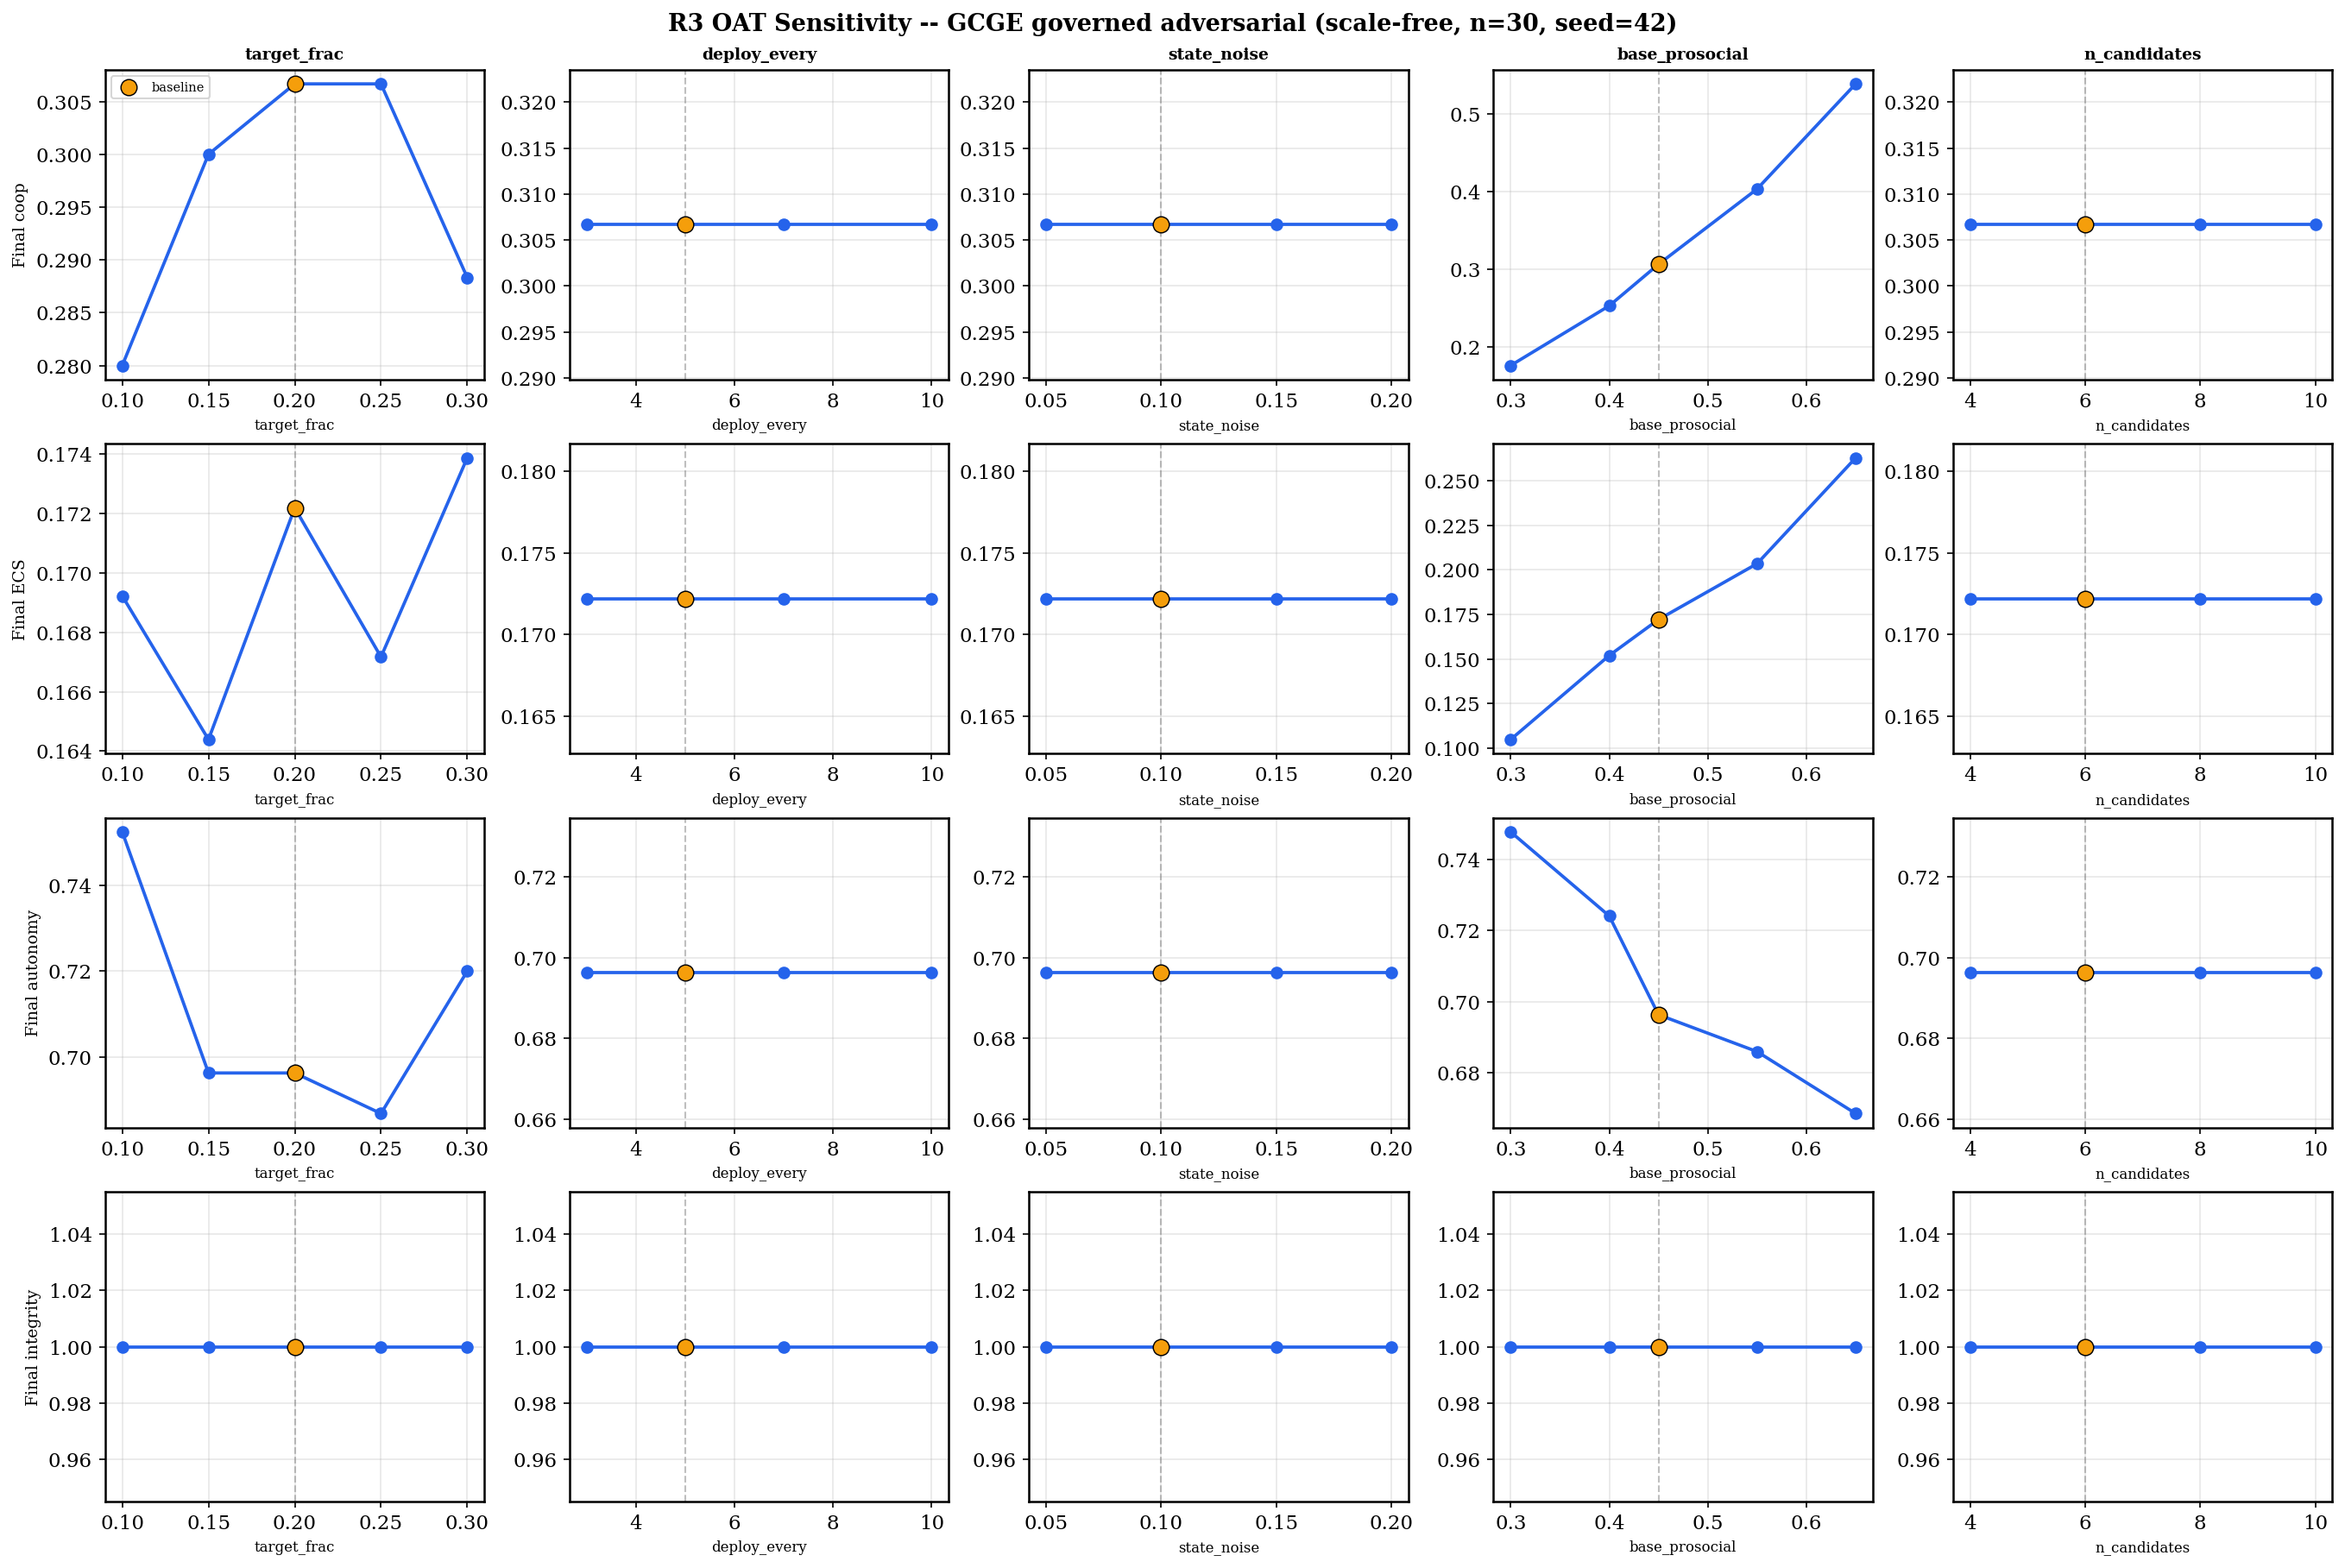

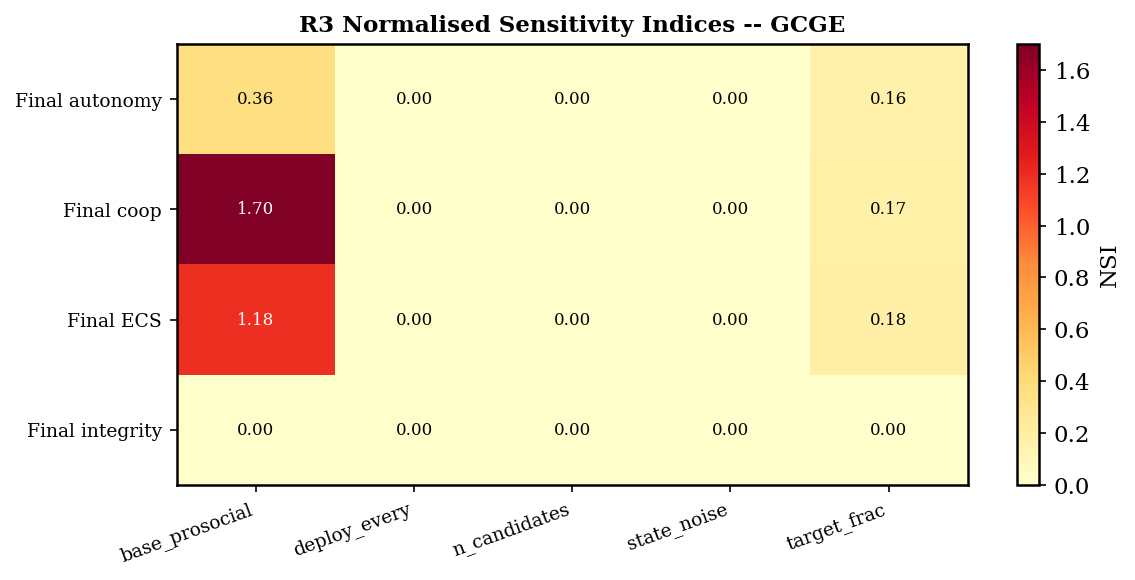

Saved -> ./paper5_v4/sensitivity/sensitivity_analysis.png + nsi_heatmap.png


In [52]:
# ============================================================
# R3-c) SENSITIVITY PLOTS  (4 metrics x 5 params + NSI heatmap)
# ============================================================
PARAM_LABELS = {
    "target_frac":    "target_frac",
    "deploy_every":   "deploy_every",
    "state_noise":    "state_noise",
    "base_prosocial": "base_prosocial",
    "n_candidates":   "n_candidates",
}

n_metrics = len(SA_TARGETS)
n_params  = len(SA_GRID)
fig, axes = plt.subplots(n_metrics, n_params,
                         figsize=(3.6 * n_params, 3.0 * n_metrics),
                         constrained_layout=True)
fig.suptitle("R3 OAT Sensitivity -- GCGE governed adversarial "
             "(scale-free, n=30, seed=42)",
             fontsize=13, fontweight="bold")

for row_i, (metric_key, metric_label) in enumerate(SA_TARGETS.items()):
    for col_i, param in enumerate(SA_GRID):
        ax  = axes[row_i][col_i]
        sub = sa_df[sa_df["param_name"] == param].sort_values("param_value")
        xs  = sub["param_value"].values
        ys  = sub[metric_key].values
        bx  = SA_BASELINE[param]
        brow = sub[sub["is_baseline"]]
        by  = float(brow[metric_key].values[0]) if len(brow) > 0 else None
        ax.plot(xs, ys, "o-", color="#2563EB", lw=1.8, ms=6)
        if by is not None:
            ax.axvline(bx, color="gray", ls="--", alpha=0.5, lw=1)
            ax.scatter([bx], [by], color="#F59E0B", s=80, zorder=5,
                       edgecolors="black", linewidths=0.7,
                       label="baseline" if (row_i == 0 and col_i == 0) else None)
        ax.set_xlabel(PARAM_LABELS[param], fontsize=8)
        if col_i == 0:
            ax.set_ylabel(metric_label, fontsize=9)
        if row_i == 0:
            ax.set_title(PARAM_LABELS[param], fontsize=9, fontweight="bold")
        if row_i == 0 and col_i == 0:
            ax.legend(fontsize=7, loc="best")
        ax.grid(True, alpha=0.3)

plt.savefig(os.path.join(BASE_SA, "sensitivity_analysis.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(BASE_SA, "sensitivity_analysis.pdf"),
            bbox_inches="tight")
plt.show(); plt.close()

# NSI heatmap
fig, ax = plt.subplots(figsize=(8, 4))
mat = nsi_pivot.values  # rows=params, cols=metrics
im  = ax.imshow(mat.T, aspect="auto", cmap="YlOrRd",
                vmin=0, vmax=max(0.5, np.nanmax(mat)))
ax.set_xticks(range(len(nsi_pivot.index)))
ax.set_xticklabels([PARAM_LABELS.get(p, p) for p in nsi_pivot.index],
                   rotation=20, ha="right", fontsize=9)
ax.set_yticks(range(len(nsi_pivot.columns)))
ax.set_yticklabels([SA_TARGETS[m] for m in nsi_pivot.columns], fontsize=9)
plt.colorbar(im, ax=ax, label="NSI")
ax.set_title("R3 Normalised Sensitivity Indices -- GCGE",
             fontsize=11, fontweight="bold")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat[i, j]
        ax.text(i, j, f"{v:.2f}", ha="center", va="center",
                fontsize=8, color="white" if v > 0.6 else "black")

plt.tight_layout()
plt.savefig(os.path.join(BASE_SA, "nsi_heatmap.png"),
            dpi=300, bbox_inches="tight")
plt.show(); plt.close()
print(f"Saved -> {BASE_SA}/sensitivity_analysis.png + nsi_heatmap.png")


### R4 -- LLM Temperature Robustness

Sweep the **agent** LLM temperature in {0.0, 0.2, 0.5, 0.8} while holding
the compiler temperature fixed at the paper baseline (0.25). T=0 gives
deterministic (greedy) narrative-shift evaluations; higher temperatures
inject variability into the agent-side response. Run under both
governed and unconstrained adversarial conditions to test whether the
ECS gap is preserved when the agent advisory channel is more or less
stochastic.


In [53]:
# ============================================================
# R4) LLM TEMPERATURE ROBUSTNESS  (agent-side temp sweep)
# ============================================================
TEMPS_R4    = [0.0, 0.2, 0.5, 0.8]
CONDS_R4    = ["governed", "unconstrained"]
BASE_R4     = ensure_dir(os.path.join(V4_BASE, "temperature"))
temp_records = []

print("Running agent-temperature sweep ...")
print(f"  Temps:      {TEMPS_R4}")
print(f"  Conditions: {CONDS_R4}")
print(f"  Total runs: {len(TEMPS_R4) * len(CONDS_R4)}\n")

for temp in TEMPS_R4:
    # Fresh agent LLM per temperature (cache-isolated to avoid cross-temp leakage)
    ag_llm_t = NebiusLLM(client=client, model=AGENT_MODEL,
                         temperature=temp, max_tokens=250,
                         role=f"agent-T{temp}", cache_enabled=True)
    for mode in CONDS_R4:
        label = f"{mode}-T{temp:.1f}"
        out   = ensure_dir(os.path.join(BASE_R4, label))
        cfg   = GCGEConfig(
            n_agents=30, topo="scale_free", steps=50, seed=42,
            adversarial=True, governance_mode=mode,
            n_candidates=6, label=label,
        )
        df, _, audits = run_gcge(cfg, out, comp_llm, ag_llm_t, verbose=False)
        s = gcge_summary_row(df, audits, cfg, condition=mode, agent_temp=temp)
        temp_records.append(s)
        print(f"  [T={temp:.1f} | {mode:13s}]  "
              f"coop={s['coop_final']:.3f}  ECS={s['ecs_final']:.3f}  "
              f"auto={s['autonomy_final']:.3f}  integ={s['integrity_final']:.3f}")

temp_df = pd.DataFrame(temp_records)
temp_df.to_csv(os.path.join(BASE_R4, "temperature_summary.csv"), index=False)
print(f"\nSaved -> {BASE_R4}/temperature_summary.csv")


Running agent-temperature sweep ...
  Temps:      [0.0, 0.2, 0.5, 0.8]
  Conditions: ['governed', 'unconstrained']
  Total runs: 8

  [T=0.0 | governed     ]  coop=0.310  ECS=0.174  auto=0.692  integ=1.000
  [T=0.0 | unconstrained]  coop=0.270  ECS=0.000  auto=0.864  integ=0.000
  [T=0.2 | governed     ]  coop=0.312  ECS=0.174  auto=0.694  integ=1.000
  [T=0.2 | unconstrained]  coop=0.272  ECS=0.000  auto=0.832  integ=0.000
  [T=0.5 | governed     ]  coop=0.313  ECS=0.175  auto=0.690  integ=1.000
  [T=0.5 | unconstrained]  coop=0.273  ECS=0.000  auto=0.840  integ=0.000
  [T=0.8 | governed     ]  coop=0.298  ECS=0.170  auto=0.702  integ=1.000
  [T=0.8 | unconstrained]  coop=0.275  ECS=0.000  auto=0.847  integ=0.000

Saved -> ./paper5_v4/temperature/temperature_summary.csv


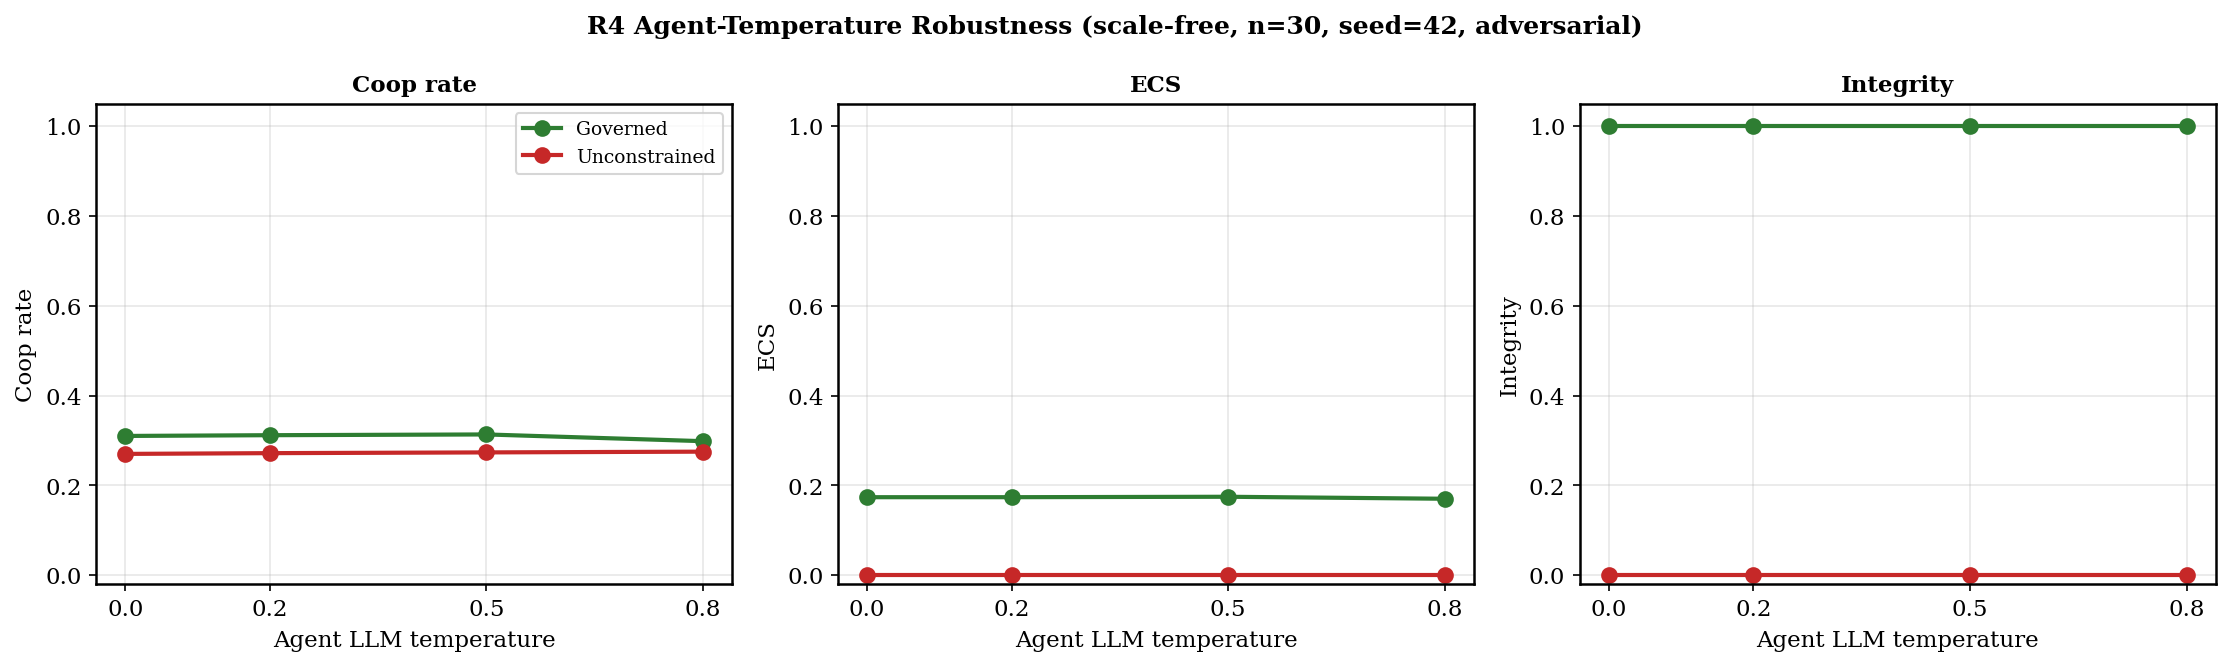

Saved -> ./paper5_v4/temperature/temperature_robustness.png


In [54]:
# ============================================================
# R4-b) TEMPERATURE PLOTS  (line plots: ECS / coop / integrity vs T)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("R4 Agent-Temperature Robustness "
             "(scale-free, n=30, seed=42, adversarial)",
             fontsize=12, fontweight="bold")

for ax, metric in zip(axes, ["coop_final", "ecs_final", "integrity_final"]):
    for mode in CONDS_R4:
        sub = temp_df[temp_df["condition"] == mode].sort_values("agent_temp")
        ax.plot(sub["agent_temp"], sub[metric],
                "o-", color=V4_COLORS[mode], lw=2, ms=7,
                label=mode.capitalize() if ax is axes[0] else None)
    ax.set_xlabel("Agent LLM temperature")
    ax.set_ylabel(V4_METRIC_LABELS[metric])
    ax.set_title(V4_METRIC_LABELS[metric], fontsize=11, fontweight="bold")
    ax.set_xticks(TEMPS_R4)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.02, 1.05)
    if ax is axes[0]:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(BASE_R4, "temperature_robustness.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(BASE_R4, "temperature_robustness.pdf"),
            bbox_inches="tight")
plt.show(); plt.close()
print(f"Saved -> {BASE_R4}/temperature_robustness.png")


### R5 -- Multi-Model Sweep + Heterogeneous Backbones

The paper's Limitations section explicitly flags single-backbone
evaluation: *the agent population is governed by a single LLM backbone
(Llama-3.3-70B-Instruct) ... heterogeneous backbone pools (e.g., a
Llama coordinator governing a population of DeepSeek and Qwen agents)*.

R5 closes this gap with two complementary sweeps:

**R5-A.** Five backbones used **homogeneously** (same model on the
compiler and agent sides) under governed and unconstrained adversarial.
Tests whether the ECS gap is robust across model families.

**R5-B.** **Heterogeneous backbones**: Llama-3.3-70B coordinator paired
with DeepSeek / Qwen / Hermes agents (and the symmetric reverse).
Tests whether the governance benefit transfers when the coordinator and
agent populations come from different model families with different
RLHF cooperative biases.


In [55]:
# ============================================================
# R5-A) HOMOGENEOUS MULTI-MODEL SWEEP
# ============================================================
MODELS_R5 = {
    "Llama-70B":    "meta-llama/Llama-3.3-70B-Instruct",
    "Llama-8B":     "meta-llama/Meta-Llama-3.1-8B-Instruct",
    "DeepSeek-V3":  "deepseek-ai/DeepSeek-V3",
    "Qwen3-235B":   "Qwen/Qwen3-235B-A22B-Instruct-2507",
    "Hermes-4-70B": "NousResearch/Hermes-4-70B",
}
CONDS_R5  = ["governed", "unconstrained"]
BASE_R5A  = ensure_dir(os.path.join(V4_BASE, "multi_model_homo"))
mm_records = []

print("R5-A) Homogeneous multi-model sweep ...")
print(f"  Models:     {list(MODELS_R5.keys())}")
print(f"  Conditions: {CONDS_R5}")
print(f"  Total runs: {len(MODELS_R5) * len(CONDS_R5)}\n")

for model_label, model_id in MODELS_R5.items():
    # Fresh dual-LLM stack per model (compiler temp 0.25, agent temp 0.30)
    try:
        comp_m = NebiusLLM(client=client, model=model_id,
                           temperature=0.25, max_tokens=400,
                           role=f"compiler-{model_label}", cache_enabled=True)
        ag_m   = NebiusLLM(client=client, model=model_id,
                           temperature=0.30, max_tokens=250,
                           role=f"agent-{model_label}", cache_enabled=True)
    except Exception as e:
        print(f"  [{model_label}]  init ERROR: {e}")
        continue

    for mode in CONDS_R5:
        label = f"{mode}-{model_label}"
        out   = ensure_dir(os.path.join(BASE_R5A, label))
        cfg   = GCGEConfig(
            n_agents=30, topo="scale_free", steps=50, seed=42,
            adversarial=True, governance_mode=mode,
            n_candidates=6, label=label,
        )
        try:
            df, _, audits = run_gcge(cfg, out, comp_m, ag_m, verbose=False)
            s = gcge_summary_row(df, audits, cfg,
                                 condition=mode, model=model_label,
                                 model_id=model_id)
            mm_records.append(s)
            print(f"  [{model_label:13s} | {mode:13s}]  "
                  f"coop={s['coop_final']:.3f}  ECS={s['ecs_final']:.3f}  "
                  f"integ={s['integrity_final']:.3f}")
        except Exception as e:
            print(f"  [{model_label:13s} | {mode:13s}]  ERROR: {e}")

mm_df = pd.DataFrame(mm_records)
mm_df.to_csv(os.path.join(BASE_R5A, "multi_model_summary.csv"), index=False)
print(f"\nSaved -> {BASE_R5A}/multi_model_summary.csv")


R5-A) Homogeneous multi-model sweep ...
  Models:     ['Llama-70B', 'Llama-8B', 'DeepSeek-V3', 'Qwen3-235B', 'Hermes-4-70B']
  Conditions: ['governed', 'unconstrained']
  Total runs: 10

  [Llama-70B     | governed     ]  coop=0.312  ECS=0.171  integ=1.000
  [Llama-70B     | unconstrained]  coop=0.268  ECS=0.000  integ=0.000
  [Llama-8B      | governed     ]  coop=0.282  ECS=0.182  integ=1.000
  [Llama-8B      | unconstrained]  coop=0.272  ECS=0.000  integ=0.000
  [DeepSeek-V3   | governed     ]  coop=0.252  ECS=0.212  integ=1.000
  [DeepSeek-V3   | unconstrained]  coop=0.292  ECS=0.000  integ=0.000
  [Qwen3-235B    | governed     ]  coop=0.280  ECS=0.148  integ=1.000
  [Qwen3-235B    | unconstrained]  coop=0.260  ECS=0.000  integ=0.000
  [Hermes-4-70B  | governed     ]  coop=0.278  ECS=0.138  integ=1.000
  [Hermes-4-70B  | unconstrained]  coop=0.270  ECS=0.000  integ=0.000

Saved -> ./paper5_v4/multi_model_homo/multi_model_summary.csv


In [56]:
# ============================================================
# R5-B) HETEROGENEOUS BACKBONES  (Llama coordinator x non-Llama agents)
# ============================================================
LLAMA_ID = "meta-llama/Llama-3.3-70B-Instruct"
HETERO_PAIRS = [
    ("Llama-70B",    "DeepSeek-V3"),   # Llama coord, DeepSeek agents
    ("Llama-70B",    "Qwen3-235B"),    # Llama coord, Qwen agents
    ("Llama-70B",    "Hermes-4-70B"),  # Llama coord, Hermes agents
    ("DeepSeek-V3",  "Llama-70B"),     # DeepSeek coord, Llama agents
    ("Qwen3-235B",   "Llama-70B"),     # Qwen coord,     Llama agents
]

BASE_R5B  = ensure_dir(os.path.join(V4_BASE, "multi_model_hetero"))
ht_records = []

print("R5-B) Heterogeneous-backbone sweep ...")
print(f"  Pairs:      {HETERO_PAIRS}")
print(f"  Conditions: {CONDS_R5}")
print(f"  Total runs: {len(HETERO_PAIRS) * len(CONDS_R5)}\n")

for comp_label, ag_label in HETERO_PAIRS:
    comp_id = MODELS_R5[comp_label]
    ag_id   = MODELS_R5[ag_label]
    pair_lbl = f"{comp_label}->{ag_label}"
    try:
        comp_m = NebiusLLM(client=client, model=comp_id,
                           temperature=0.25, max_tokens=400,
                           role=f"comp-{comp_label}", cache_enabled=True)
        ag_m   = NebiusLLM(client=client, model=ag_id,
                           temperature=0.30, max_tokens=250,
                           role=f"ag-{ag_label}", cache_enabled=True)
    except Exception as e:
        print(f"  [{pair_lbl}]  init ERROR: {e}")
        continue

    for mode in CONDS_R5:
        label = f"{mode}-{comp_label}-{ag_label}"
        out   = ensure_dir(os.path.join(BASE_R5B, label))
        cfg   = GCGEConfig(
            n_agents=30, topo="scale_free", steps=50, seed=42,
            adversarial=True, governance_mode=mode,
            n_candidates=6, label=label,
        )
        try:
            df, _, audits = run_gcge(cfg, out, comp_m, ag_m, verbose=False)
            s = gcge_summary_row(df, audits, cfg,
                                 condition=mode,
                                 compiler_model=comp_label,
                                 agent_model=ag_label,
                                 pair=pair_lbl)
            ht_records.append(s)
            print(f"  [{pair_lbl:30s} | {mode:13s}]  "
                  f"coop={s['coop_final']:.3f}  ECS={s['ecs_final']:.3f}  "
                  f"integ={s['integrity_final']:.3f}")
        except Exception as e:
            print(f"  [{pair_lbl:30s} | {mode:13s}]  ERROR: {e}")

ht_df = pd.DataFrame(ht_records)
ht_df.to_csv(os.path.join(BASE_R5B, "hetero_backbone_summary.csv"), index=False)
print(f"\nSaved -> {BASE_R5B}/hetero_backbone_summary.csv")


R5-B) Heterogeneous-backbone sweep ...
  Pairs:      [('Llama-70B', 'DeepSeek-V3'), ('Llama-70B', 'Qwen3-235B'), ('Llama-70B', 'Hermes-4-70B'), ('DeepSeek-V3', 'Llama-70B'), ('Qwen3-235B', 'Llama-70B')]
  Conditions: ['governed', 'unconstrained']
  Total runs: 10

  [Llama-70B->DeepSeek-V3         | governed     ]  coop=0.292  ECS=0.250  integ=1.000
  [Llama-70B->DeepSeek-V3         | unconstrained]  coop=0.292  ECS=0.000  integ=0.000
  [Llama-70B->Qwen3-235B          | governed     ]  coop=0.270  ECS=0.158  integ=1.000
  [Llama-70B->Qwen3-235B          | unconstrained]  coop=0.267  ECS=0.000  integ=0.000
  [Llama-70B->Hermes-4-70B        | governed     ]  coop=0.283  ECS=0.144  integ=1.000
  [Llama-70B->Hermes-4-70B        | unconstrained]  coop=0.270  ECS=0.000  integ=0.000
  [DeepSeek-V3->Llama-70B         | governed     ]  coop=0.248  ECS=0.206  integ=1.000
  [DeepSeek-V3->Llama-70B         | unconstrained]  coop=0.292  ECS=0.000  integ=0.000
  [Qwen3-235B->Llama-70B          | gov

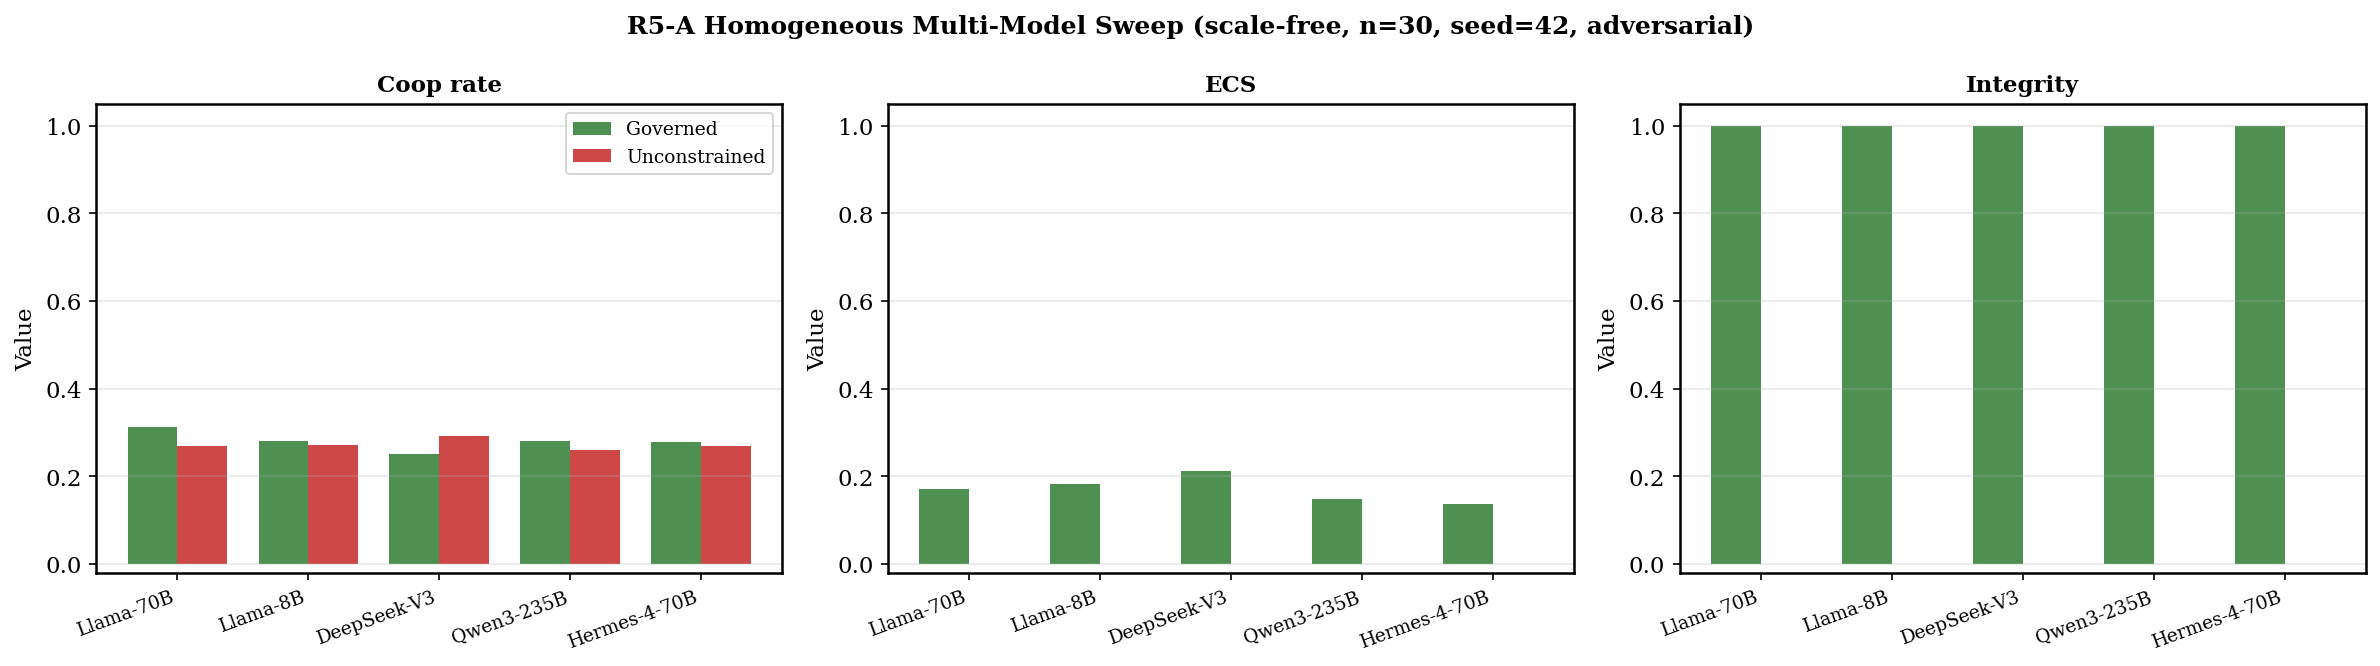

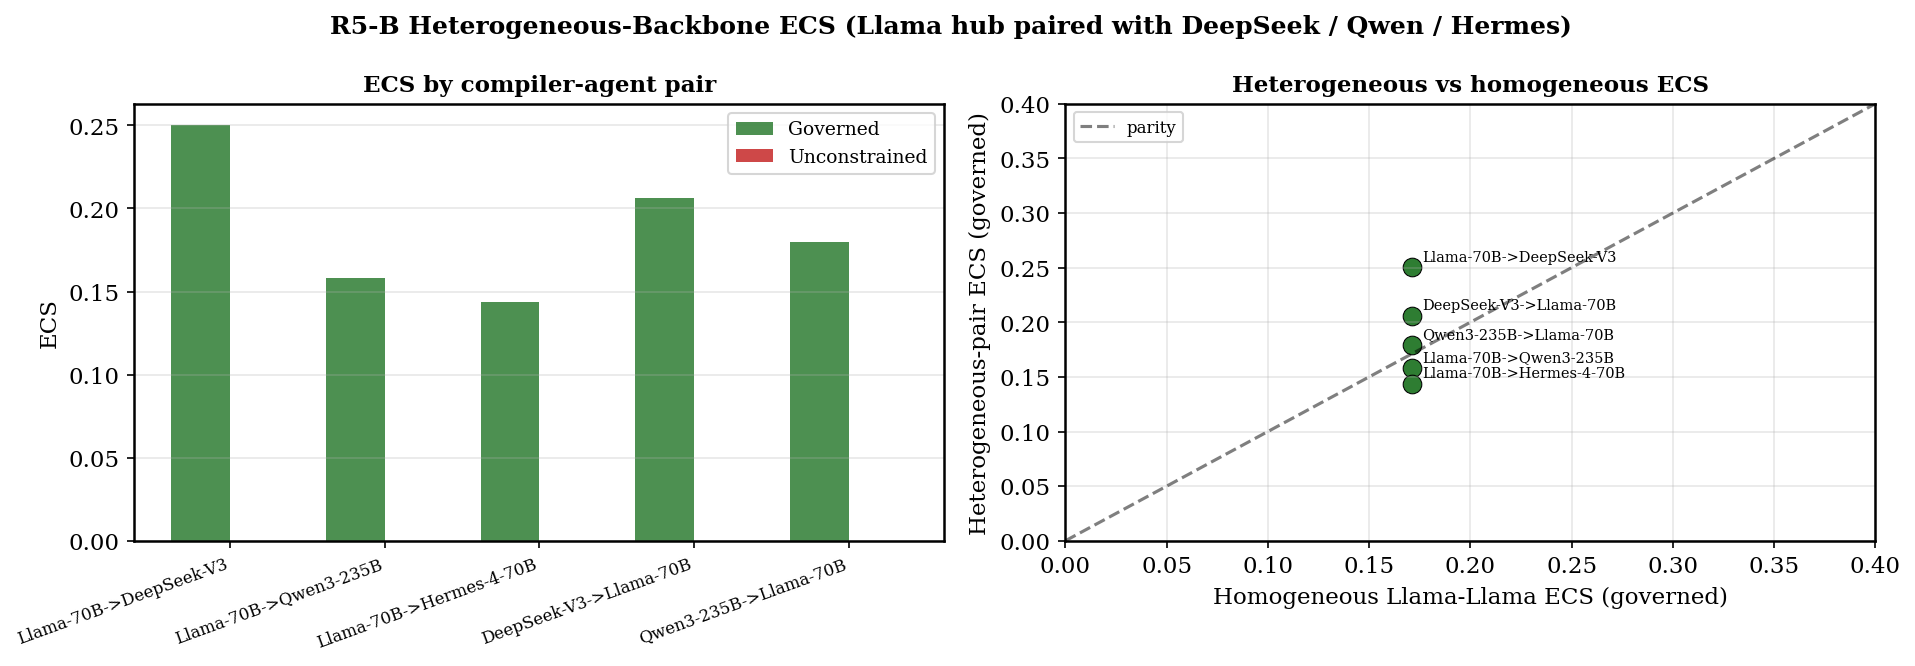

Saved -> ./paper5_v4/multi_model_homo/  +  ./paper5_v4/multi_model_hetero/


In [57]:
# ============================================================
# R5-c) MULTI-MODEL PLOTS  (homogeneous bars + heterogeneous matrix)
# ============================================================
# Panel 1: homogeneous bar chart of ECS by model x condition
if len(mm_df) > 0:
    models_present = mm_df["model"].unique().tolist()
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle("R5-A Homogeneous Multi-Model Sweep "
                 "(scale-free, n=30, seed=42, adversarial)",
                 fontsize=12, fontweight="bold")

    for ax, metric in zip(axes, ["coop_final", "ecs_final", "integrity_final"]):
        width = 0.38
        x_pos = np.arange(len(models_present))
        for j, mode in enumerate(CONDS_R5):
            vals = []
            for m in models_present:
                row = mm_df[(mm_df["model"] == m) & (mm_df["condition"] == mode)]
                vals.append(float(row[metric].values[0]) if len(row) else np.nan)
            ax.bar(x_pos + (j - 0.5) * width, vals, width=width,
                   color=V4_COLORS[mode], alpha=0.85,
                   label=mode.capitalize() if ax is axes[0] else None)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(models_present, rotation=20, ha="right", fontsize=9)
        ax.set_title(V4_METRIC_LABELS[metric], fontsize=11, fontweight="bold")
        ax.set_ylabel("Value"); ax.grid(True, axis="y", alpha=0.3)
        ax.set_ylim(-0.02, 1.05)
        if ax is axes[0]:
            ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_R5A, "multi_model_bars.png"),
                dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(BASE_R5A, "multi_model_bars.pdf"),
                bbox_inches="tight")
    plt.show(); plt.close()

# Panel 2: heterogeneous-pair ECS matrix (governed only) + parity plot
if len(ht_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle("R5-B Heterogeneous-Backbone ECS "
                 "(Llama hub paired with DeepSeek / Qwen / Hermes)",
                 fontsize=12, fontweight="bold")
    ax = axes[0]
    pairs = ht_df["pair"].unique().tolist()
    width = 0.38
    x_pos = np.arange(len(pairs))
    for j, mode in enumerate(CONDS_R5):
        vals = []
        for p in pairs:
            row = ht_df[(ht_df["pair"] == p) & (ht_df["condition"] == mode)]
            vals.append(float(row["ecs_final"].values[0]) if len(row) else np.nan)
        ax.bar(x_pos + (j - 0.5) * width, vals, width=width,
               color=V4_COLORS[mode], alpha=0.85,
               label=mode.capitalize())
    ax.set_xticks(x_pos)
    ax.set_xticklabels(pairs, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("ECS"); ax.set_title("ECS by compiler-agent pair",
                                       fontsize=11, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3); ax.legend(fontsize=9)

    # Parity plot: homogeneous Llama-Llama ECS vs heterogeneous-pair ECS
    ax = axes[1]
    if "Llama-70B" in mm_df["model"].values:
        llama_g = float(mm_df[(mm_df["model"] == "Llama-70B")
                              & (mm_df["condition"] == "governed")]
                              ["ecs_final"].values[0])
        for p in pairs:
            row_g = ht_df[(ht_df["pair"] == p)
                          & (ht_df["condition"] == "governed")]
            if len(row_g):
                y = float(row_g["ecs_final"].values[0])
                ax.scatter(llama_g, y, s=80, color="#2E7D32",
                           edgecolors="black", linewidths=0.5)
                ax.annotate(p, (llama_g, y), fontsize=7,
                            xytext=(5, 3), textcoords="offset points")
        lo = 0; hi = max(0.4, llama_g + 0.05)
        ax.plot([lo, hi], [lo, hi], "k--", alpha=0.5, label="parity")
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_xlabel("Homogeneous Llama-Llama ECS (governed)")
        ax.set_ylabel("Heterogeneous-pair ECS (governed)")
        ax.set_title("Heterogeneous vs homogeneous ECS",
                     fontsize=11, fontweight="bold")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_R5B, "hetero_backbone_summary.png"),
                dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(BASE_R5B, "hetero_backbone_summary.pdf"),
                bbox_inches="tight")
    plt.show(); plt.close()

print(f"Saved -> {BASE_R5A}/  +  {BASE_R5B}/")


In [58]:
# ============================================================
# R5-d) CROSS-MODEL ECS-GAP TABLE
# ============================================================
print("=" * 70)
print("R5 SUMMARY: ECS gap (governed - unconstrained) by configuration")
print("=" * 70)

# Homogeneous gaps
if len(mm_df) > 0:
    print("\nHomogeneous (same backbone on compiler + agents):")
    print(f"  {'Model':<14} {'ECS gov':>9} {'ECS unc':>9} {'gap':>9}")
    for m in mm_df["model"].unique():
        g = mm_df[(mm_df["model"] == m) & (mm_df["condition"] == "governed")]
        u = mm_df[(mm_df["model"] == m) & (mm_df["condition"] == "unconstrained")]
        if len(g) and len(u):
            ecs_g = float(g["ecs_final"].values[0])
            ecs_u = float(u["ecs_final"].values[0])
            print(f"  {m:<14} {ecs_g:9.3f} {ecs_u:9.3f} {ecs_g - ecs_u:+9.3f}")

# Heterogeneous gaps
if len(ht_df) > 0:
    print("\nHeterogeneous (compiler != agent backbone):")
    print(f"  {'Pair':<32} {'ECS gov':>9} {'ECS unc':>9} {'gap':>9}")
    for p in ht_df["pair"].unique():
        g = ht_df[(ht_df["pair"] == p) & (ht_df["condition"] == "governed")]
        u = ht_df[(ht_df["pair"] == p) & (ht_df["condition"] == "unconstrained")]
        if len(g) and len(u):
            ecs_g = float(g["ecs_final"].values[0])
            ecs_u = float(u["ecs_final"].values[0])
            print(f"  {p:<32} {ecs_g:9.3f} {ecs_u:9.3f} {ecs_g - ecs_u:+9.3f}")


R5 SUMMARY: ECS gap (governed - unconstrained) by configuration

Homogeneous (same backbone on compiler + agents):
  Model            ECS gov   ECS unc       gap
  Llama-70B          0.171     0.000    +0.171
  Llama-8B           0.182     0.000    +0.182
  DeepSeek-V3        0.212     0.000    +0.212
  Qwen3-235B         0.148     0.000    +0.148
  Hermes-4-70B       0.138     0.000    +0.138

Heterogeneous (compiler != agent backbone):
  Pair                               ECS gov   ECS unc       gap
  Llama-70B->DeepSeek-V3               0.250     0.000    +0.250
  Llama-70B->Qwen3-235B                0.158     0.000    +0.158
  Llama-70B->Hermes-4-70B              0.144     0.000    +0.144
  DeepSeek-V3->Llama-70B               0.206     0.000    +0.206
  Qwen3-235B->Llama-70B                0.180     0.000    +0.180


### Final -- Package All v4 Outputs

Bundle every CSV / PNG / PDF produced by the v4 sections (R1-R5) into a
single ZIP for archiving, paper supplementaries, or upload to a code
repository.


In [59]:
# ============================================================
# PACKAGE ALL v4 OUTPUTS
# ============================================================
import zipfile, pathlib

zip_path = "./gcge_paper5_v4_results.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in pathlib.Path(V4_BASE).rglob("*"):
        if p.is_file():
            zf.write(p, p.relative_to("./"))

size_mb = pathlib.Path(zip_path).stat().st_size / 1e6
print(f"v4 archive: {zip_path}  ({size_mb:.1f} MB)\n")
print("v4 output tree:")
for p in sorted(pathlib.Path(V4_BASE).rglob("*")):
    if p.is_file():
        print(f"  {str(p.relative_to(V4_BASE)):65s} {p.stat().st_size/1e3:7.1f} KB")

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print("\n(Not in Colab -- archive available at the path above.)")

print("\nDone. All GCGE v4 sections complete.")
print(f"  Compiler LLM stats: {comp_llm.stats}")
print(f"  Agent LLM stats:    {ag_llm.stats}")


v4 archive: ./gcge_paper5_v4_results.zip  (2.4 MB)

v4 output tree:
  multi_model_hetero/governed-DeepSeek-V3-Llama-70B/agents.csv          2.9 KB
  multi_model_hetero/governed-DeepSeek-V3-Llama-70B/config.json         0.7 KB
  multi_model_hetero/governed-DeepSeek-V3-Llama-70B/policy_log.csv      0.9 KB
  multi_model_hetero/governed-DeepSeek-V3-Llama-70B/timeseries.csv     10.2 KB
  multi_model_hetero/governed-Llama-70B-DeepSeek-V3/agents.csv          2.9 KB
  multi_model_hetero/governed-Llama-70B-DeepSeek-V3/config.json         0.7 KB
  multi_model_hetero/governed-Llama-70B-DeepSeek-V3/policy_log.csv      0.9 KB
  multi_model_hetero/governed-Llama-70B-DeepSeek-V3/timeseries.csv      9.7 KB
  multi_model_hetero/governed-Llama-70B-Hermes-4-70B/agents.csv         2.9 KB
  multi_model_hetero/governed-Llama-70B-Hermes-4-70B/config.json        0.7 KB
  multi_model_hetero/governed-Llama-70B-Hermes-4-70B/policy_log.csv     0.9 KB
  multi_model_hetero/governed-Llama-70B-Hermes-4-70B/timeseries